## 0 · Setup & Imports

In [1]:
# ── Bootstrap: locate src/ ────────────────────────────────────────────────
import sys, os

_here           = os.getcwd()
_root_candidate = os.path.dirname(_here)
for _p in [os.path.join(_here, 'src'),
           os.path.join(_root_candidate, 'src')]:
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break

# ── Shared path resolver ──────────────────────────────────────────────────
from path_config import DATA_DIR, make_output_dir, data_path, print_paths
print_paths()

OUTPUT_DIR = make_output_dir('project5')
print(f'\n📁 Outputs : {OUTPUT_DIR}')

# ── Standard imports ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker  as mticker
import seaborn as sns
from scipy import stats
import re
from collections import Counter

# ── Social-media colour palette ───────────────────────────────────────────
PAL = {
    'positive'  : '#2E7D32',
    'negative'  : '#C62828',
    'neutral'   : '#1565C0',
    'twitter'   : '#1DA1F2',
    'instagram' : '#E1306C',
    'facebook'  : '#1877F2',
    'bg'        : '#F8F9FA',
    'grid'      : '#E0E0E0',
    'highlight' : '#FF6F00',
}

PLATFORM_COLORS = {
    'Twitter'  : PAL['twitter'],
    'Instagram': PAL['instagram'],
    'Facebook' : PAL['facebook'],
}

# Sentiment polarity buckets
POSITIVE_EMOTIONS = {
    'Positive','Joy','Excitement','Contentment','Gratitude','Happy','Hopeful',
    'Awe','Serenity','Pride','Elation','Euphoria','Enthusiasm','Determination',
    'Inspiration','Happiness','Hope','Empowerment','Inspired','Admiration',
    'Calmness','Compassion','Fulfillment','Proud','Grateful','Compassionate',
    'Thrill','Enchantment','Love','Amusement','Anticipation','Enjoyment',
    'Affection','Adoration','Zest','Radiance','Rejuvenation','Coziness',
    'Resilience','Playful','Adventure','Satisfaction','Accomplishment',
    'Harmony','Creativity','Wonder',
}
NEGATIVE_EMOTIONS = {
    'Negative','Despair','Grief','Loneliness','Sad','Frustration','Regret',
    'Melancholy','Hate','Bad','Disgust','Bitterness','Frustrated','Betrayal',
    'Anger','Fear','Sadness','Disappointed','Anxiety','Intimidation',
    'Helplessness','Envy','Apprehensive','Isolation','Disappointment',
    'Sorrow','Loss','Jealousy','Resentment','Jealous','Devastated','Envious',
    'Shame','Desolation','Heartbreak','Boredom','Overwhelmed','Suffering',
    'Darkness','Desperation','Heartache','Nostalgia',
}

def map_polarity(sentiment):
    s = str(sentiment).strip()
    if s in POSITIVE_EMOTIONS: return 'Positive'
    if s in NEGATIVE_EMOTIONS: return 'Negative'
    return 'Neutral'

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.facecolor': PAL['bg'],
    'axes.facecolor'  : PAL['bg'],
    'grid.color'      : PAL['grid'],
    'grid.linestyle'  : '--',
    'grid.alpha'      : 0.7,
    'figure.dpi'      : 120,
})

print('\n✅ All imports successful.')


📁 Project root : /Users/tejaspatil/Documents/Data Analysis Portfolio
📁 src/         : /Users/tejaspatil/Documents/Data Analysis Portfolio/src  (on sys.path)
📁 data/        : /Users/tejaspatil/Documents/Data Analysis Portfolio/data

📁 Outputs : /Users/tejaspatil/Documents/Data Analysis Portfolio/outputs/project5

✅ All imports successful.


In [2]:
DATA_PATH = data_path('sentimentdataset.csv')
print(f'Loading: {DATA_PATH}')

df_raw = pd.read_csv(DATA_PATH)
# Drop unnamed index columns
df_raw.drop(columns=[c for c in df_raw.columns
                     if 'Unnamed' in str(c) or c == ''], inplace=True, errors='ignore')
print(f'✅ Loaded {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(6)


Loading: /Users/tejaspatil/Documents/Data Analysis Portfolio/data/sentimentdataset.csv
✅ Loaded 732 rows × 13 columns


,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
5,Feeling grateful for the little things in lif...,Positive,2023-01-16 09:10:00,GratitudeNow,Twitter,#Gratitude #PositiveVibes,25.0,50.0,India,2023,1,16,9


In [3]:
print('Column inventory:')
print('-'*60)
for col in df_raw.columns:
    nulls   = df_raw[col].isnull().sum()
    nunique = df_raw[col].nunique()
    sample  = str(df_raw[col].dropna().iloc[0])[:40].strip()
    print(f'  {col:<15} dtype={str(df_raw[col].dtype):<10} '
          f'nulls={nulls:<4} unique={nunique:<5} sample={sample!r}')


Column inventory:
------------------------------------------------------------
  Text            dtype=object     nulls=0    unique=707   sample='Enjoying a beautiful day at the park!'
  Sentiment       dtype=object     nulls=0    unique=279   sample='Positive'
  Timestamp       dtype=object     nulls=0    unique=683   sample='2023-01-15 12:30:00'
  User            dtype=object     nulls=0    unique=685   sample='User123'
  Platform        dtype=object     nulls=0    unique=4     sample='Twitter'
  Hashtags        dtype=object     nulls=0    unique=697   sample='#Nature #Park'
  Retweets        dtype=float64    nulls=0    unique=26    sample='15.0'
  Likes           dtype=float64    nulls=0    unique=38    sample='30.0'
  Country         dtype=object     nulls=0    unique=115   sample='USA'
  Year            dtype=int64      nulls=0    unique=14    sample='2023'
  Month           dtype=int64      nulls=0    unique=12    sample='1'
  Day             dtype=int64      nulls=0    unique=31

In [4]:
df = df_raw.copy()

# ── 2.1 Strip whitespace from all string columns ──────────────────────────
str_cols = df.select_dtypes('object').columns
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

# ── 2.2 Parse Timestamp ───────────────────────────────────────────────────
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df.sort_values('Timestamp', inplace=True)
df.reset_index(drop=True, inplace=True)

# ── 2.3 Numeric columns ───────────────────────────────────────────────────
df['Retweets'] = pd.to_numeric(df['Retweets'], errors='coerce').fillna(0)
df['Likes']    = pd.to_numeric(df['Likes'],    errors='coerce').fillna(0)

# ── 2.4 Derived features ──────────────────────────────────────────────────
df['engagement']     = df['Likes'] + df['Retweets']
df['like_rt_ratio']  = (df['Likes'] / (df['Retweets'] + 1)).round(2)
df['polarity']       = df['Sentiment'].apply(map_polarity)
df['text_length']    = df['Text'].str.len()
df['word_count']     = df['Text'].str.split().str.len()
df['has_emoji']      = df['Text'].str.contains(
    r'[\U0001F300-\U0001FFFE]', regex=True, na=False)

# Time features (use existing cols, fallback to parsed Timestamp)
if 'Year'  not in df.columns: df['Year']  = df['Timestamp'].dt.year
if 'Month' not in df.columns: df['Month'] = df['Timestamp'].dt.month
if 'Hour'  not in df.columns: df['Hour']  = df['Timestamp'].dt.hour

df['Year']  = pd.to_numeric(df['Year'],  errors='coerce').fillna(0).astype(int)
df['Month'] = pd.to_numeric(df['Month'], errors='coerce').fillna(0).astype(int)
df['Hour']  = pd.to_numeric(df['Hour'],  errors='coerce').fillna(0).astype(int)
df['day_of_week'] = df['Timestamp'].dt.day_name()
df['is_weekend']  = df['Timestamp'].dt.dayofweek >= 5

# ── 2.5 Hashtag processing ────────────────────────────────────────────────
def extract_hashtags(text):
    return re.findall(r'#(\w+)', str(text))

df['hashtag_list']  = df['Hashtags'].apply(extract_hashtags)
df['hashtag_count'] = df['hashtag_list'].str.len()

# ── 2.6 Group sentiments into top-N + Other ───────────────────────────────
top_sentiments = df['Sentiment'].value_counts().nlargest(15).index
df['sentiment_grouped'] = df['Sentiment'].where(
    df['Sentiment'].isin(top_sentiments), other='Other')

print(f'✅ Cleaning complete. Shape: {df.shape}')
print(f'\n   Platforms    : {df.Platform.value_counts().to_dict()}')
print(f'   Polarity     : {df.polarity.value_counts().to_dict()}')
print(f'   Year range   : {df.Year[df.Year>0].min()} – {df.Year[df.Year>0].max()}')
print(f'   Countries    : {df.Country.nunique()}')
print(f'   Unique users : {df.User.nunique()}')
print(f'   Avg engagement: {df.engagement.mean():.1f}')
df[['Text','Sentiment','polarity','Platform','engagement',
    'text_length','has_emoji']].head(6)


✅ Cleaning complete. Shape: (732, 24)

   Platforms    : {'Instagram': 258, 'Twitter': 243, 'Facebook': 231}
   Polarity     : {'Positive': 356, 'Neutral': 210, 'Negative': 166}
   Year range   : 2010 – 2023
   Countries    : 33
   Unique users : 670
   Avg engagement: 64.4


,Text,Sentiment,polarity,Platform,engagement,text_length,has_emoji
0,"Revisiting old memories, feeling a sense of el...",Elation,Positive,Twitter,60.0,52,False
1,Contentment in the simplicity of a quiet Sunday.,Contentment,Positive,Twitter,90.0,48,False
2,Contentment in the embrace of a loved one.,Contentment,Positive,Twitter,90.0,42,False
3,"Embracing the beauty of nature, a moment of co...",Contentment,Positive,Facebook,75.0,56,False
4,Serenity found in the beauty of a sunset by th...,Serenity,Positive,Instagram,67.0,52,False
5,Feeling a sense of fulfillment after helping o...,Fulfillment,Positive,Facebook,67.0,52,False


In [5]:
print('── Engagement Statistics ──────────────────────────────────')
print(df[['Likes','Retweets','engagement','text_length','word_count']].describe().round(2))

print('\n── Posts per Platform ─────────────────────────────────────')
print(df['Platform'].value_counts())

print('\n── Polarity Breakdown ─────────────────────────────────────')
pol = df['polarity'].value_counts()
for p, n in pol.items():
    print(f'  {p:<12}: {n:>4} posts ({n/len(df)*100:.1f}%)')

print('\n── Top 15 Sentiment Labels ────────────────────────────────')
print(df['Sentiment'].value_counts().head(15).to_string())


── Engagement Statistics ──────────────────────────────────
        Likes  Retweets  engagement  text_length  word_count
count  732.00    732.00      732.00       732.00      732.00
mean    42.90     21.51       64.41        84.43       13.21
std     14.09      7.06       21.14        31.22        4.85
min     10.00      5.00       15.00        27.00        4.00
25%     34.75     17.75       52.50        56.00        9.00
50%     43.00     22.00       65.00        82.50       13.00
75%     50.00     25.00       75.00       108.00       17.00
max     80.00     40.00      120.00       156.00       25.00

── Posts per Platform ─────────────────────────────────────
Platform
Instagram    258
Twitter      243
Facebook     231
Name: count, dtype: int64

── Polarity Breakdown ─────────────────────────────────────
  Positive    :  356 posts (48.6%)
  Neutral     :  210 posts (28.7%)
  Negative    :  166 posts (22.7%)

── Top 15 Sentiment Labels ────────────────────────────────
Sentiment
Positiv

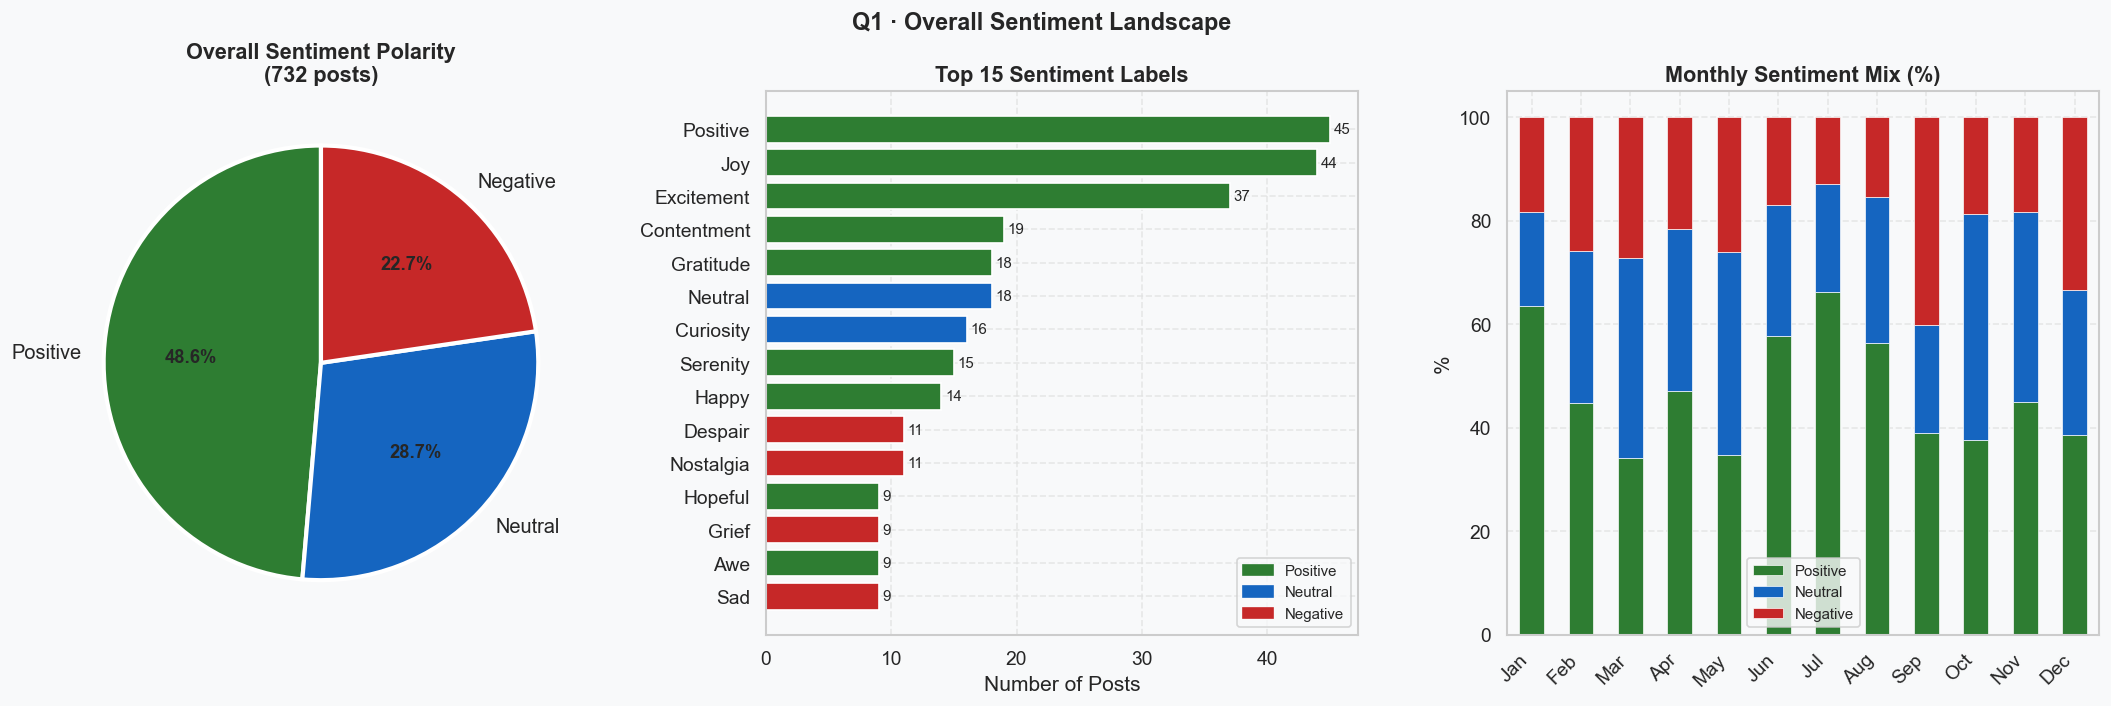

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Polarity pie ──────────────────────────────────────────────────────────
ax = axes[0]
pol_counts = df['polarity'].value_counts()[['Positive','Neutral','Negative']]
colors_pol  = [PAL['positive'], PAL['neutral'], PAL['negative']]
wedges, texts, autos = ax.pie(
    pol_counts.values,
    labels=pol_counts.index,
    colors=colors_pol,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5},
    textprops={'fontsize':12}
)
for a in autos: a.set_fontsize(11); a.set_fontweight('bold')
ax.set_title('Overall Sentiment Polarity\n(732 posts)', fontweight='bold', fontsize=13)

# ── Top 15 sentiment bar ──────────────────────────────────────────────────
ax2 = axes[1]
top15 = df['Sentiment'].value_counts().head(15)
sentiment_polarities = {s: map_polarity(s) for s in top15.index}
bar_colors = [PAL['positive'] if sentiment_polarities[s]=='Positive'
              else PAL['negative'] if sentiment_polarities[s]=='Negative'
              else PAL['neutral']
              for s in top15.index]
bars = ax2.barh(top15.index[::-1], top15.values[::-1],
                color=bar_colors[::-1], edgecolor='white')
for bar, val in zip(bars, top15.values[::-1]):
    ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=9)
ax2.set_title('Top 15 Sentiment Labels', fontweight='bold', fontsize=13)
ax2.set_xlabel('Number of Posts')
legend_els = [mpatches.Patch(color=PAL['positive'], label='Positive'),
              mpatches.Patch(color=PAL['neutral'],  label='Neutral'),
              mpatches.Patch(color=PAL['negative'], label='Negative')]
ax2.legend(handles=legend_els, fontsize=9)

# ── Sentiment heatmap by month ────────────────────────────────────────────
ax3 = axes[2]
MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_pol = df[df['Month']>0].groupby(['Month','polarity']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in monthly_pol.columns:
        monthly_pol[col] = 0
monthly_pct = monthly_pol[['Positive','Neutral','Negative']].div(
    monthly_pol.sum(axis=1), axis=0) * 100
monthly_pct.index = [MONTH_ABBR[m-1] for m in monthly_pct.index]
monthly_pct.plot(kind='bar', stacked=True, ax=ax3,
                 color=[PAL['positive'], PAL['neutral'], PAL['negative']],
                 edgecolor='white', linewidth=0.4)
ax3.set_title('Monthly Sentiment Mix (%)', fontweight='bold', fontsize=13)
ax3.set_ylabel('%'); ax3.set_xlabel('')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.legend(fontsize=9)

fig.suptitle('Q1 · Overall Sentiment Landscape', fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q1_sentiment_landscape.png'),
            dpi=150, bbox_inches='tight')
plt.show()


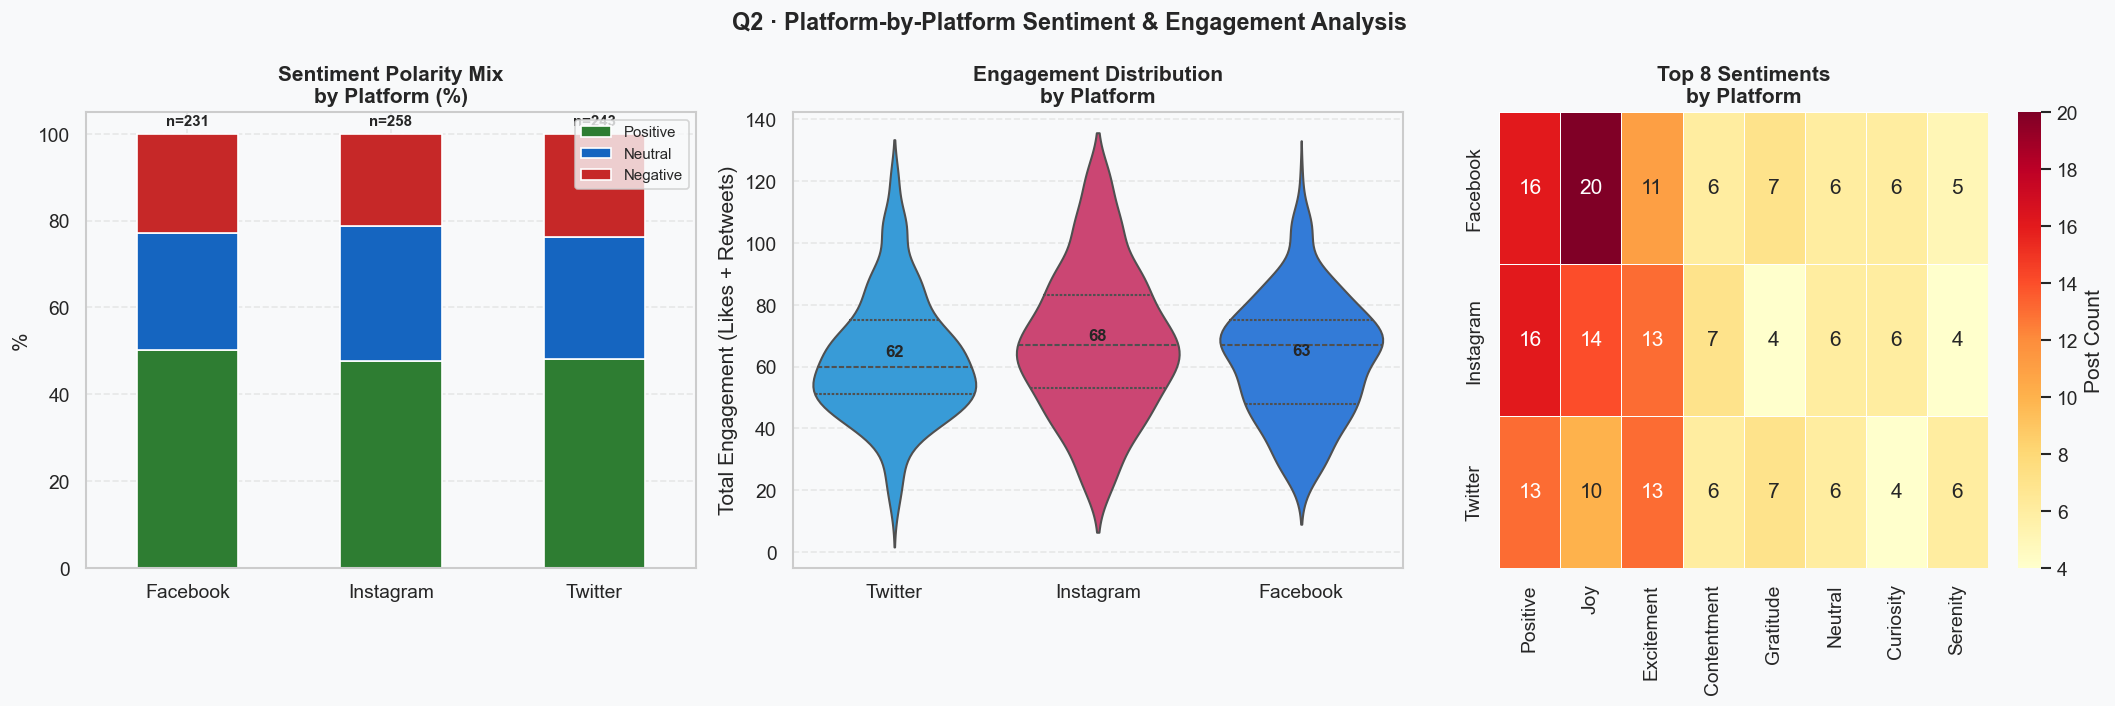


── Engagement by Platform ──────────────────────────────
          Likes        Retweets        engagement       
           mean median     mean median       mean median
Platform                                                
Facebook   41.9   45.0     21.0   22.0       62.8   67.0
Instagram  45.1   45.0     22.6   22.0       67.7   67.0
Twitter    41.6   40.0     20.9   20.0       62.4   60.0


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Stacked bar: polarity by platform ────────────────────────────────────
ax = axes[0]
plat_pol = df.groupby(['Platform','polarity']).size().unstack(fill_value=0)
for col in ['Positive','Neutral','Negative']:
    if col not in plat_pol.columns: plat_pol[col] = 0
plat_pct = plat_pol[['Positive','Neutral','Negative']].div(
    plat_pol.sum(axis=1), axis=0) * 100
plat_pct.plot(kind='bar', stacked=True, ax=ax,
              color=[PAL['positive'], PAL['neutral'], PAL['negative']],
              edgecolor='white')
ax.set_title('Sentiment Polarity Mix\nby Platform (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=9)
# Annotate total posts
for i, plat in enumerate(plat_pct.index):
    n = len(df[df['Platform']==plat])
    ax.text(i, 102, f'n={n}', ha='center', fontsize=9, fontweight='bold')

# ── Violin: engagement by platform ───────────────────────────────────────
ax2 = axes[1]
sns.violinplot(data=df, x='Platform', y='engagement',
               palette=PLATFORM_COLORS, ax=ax2, inner='quartile',
               order=['Twitter','Instagram','Facebook'])
ax2.set_title('Engagement Distribution\nby Platform', fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('Total Engagement (Likes + Retweets)')
for i, plat in enumerate(['Twitter','Instagram','Facebook']):
    m = df[df['Platform']==plat]['engagement'].mean()
    ax2.text(i, m+1, f'{m:.0f}', ha='center', fontsize=10, fontweight='bold')

# ── Top sentiment per platform heatmap ────────────────────────────────────
ax3 = axes[2]
top8_sentiments = df['Sentiment'].value_counts().head(8).index.tolist()
plat_sent = df[df['Sentiment'].isin(top8_sentiments)]\
              .groupby(['Platform','Sentiment']).size()\
              .unstack(fill_value=0)[top8_sentiments]
sns.heatmap(plat_sent, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax3, cbar_kws={'label':'Post Count'})
ax3.set_title('Top 8 Sentiments\nby Platform', fontweight='bold')
ax3.set_ylabel(''); ax3.set_xlabel('')

fig.suptitle('Q2 · Platform-by-Platform Sentiment & Engagement Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q2_platform_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\n── Engagement by Platform ──────────────────────────────')
print(df.groupby('Platform')[['Likes','Retweets','engagement']]\
        .agg(['mean','median']).round(1))


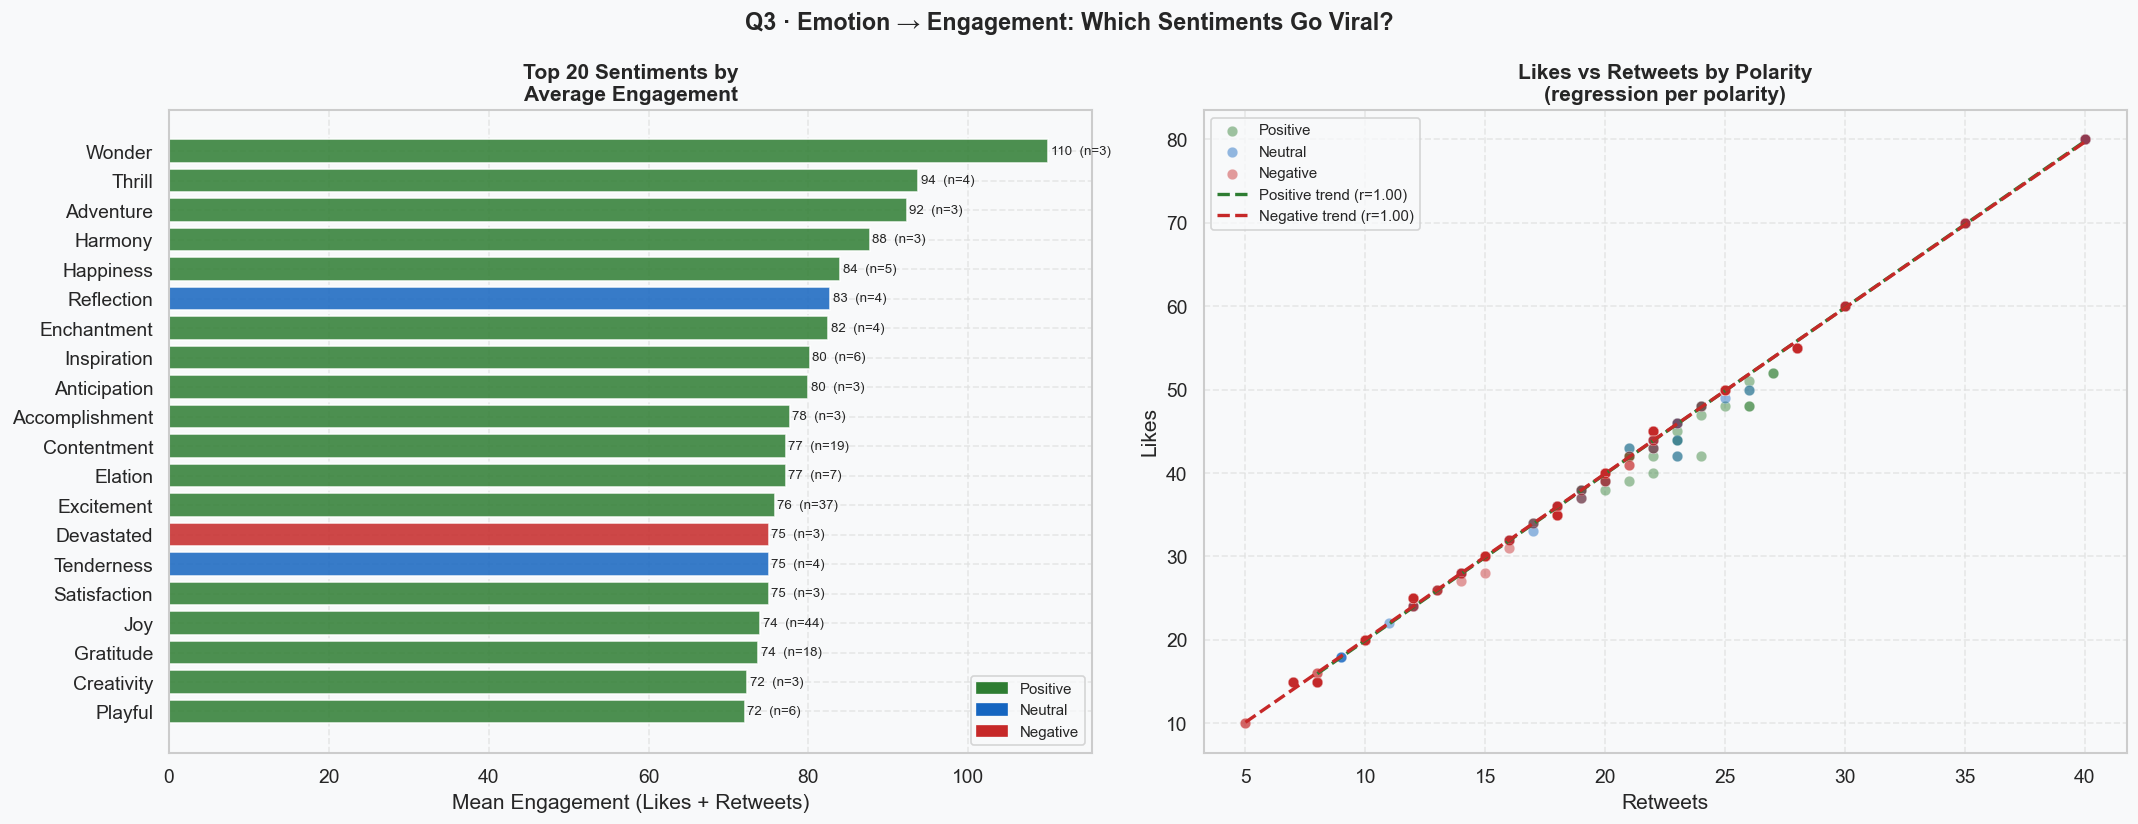

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Mean engagement per sentiment (top 20) ────────────────────────────────
ax = axes[0]
eng_by_sent = (df.groupby('Sentiment')['engagement']
                 .agg(['mean','count','sum'])
                 .query('count >= 3')
                 .sort_values('mean', ascending=False)
                 .head(20))
polarities   = [map_polarity(s) for s in eng_by_sent.index]
bar_colors   = [PAL['positive'] if p=='Positive'
                else PAL['negative'] if p=='Negative'
                else PAL['neutral']
                for p in polarities]
bars = ax.barh(eng_by_sent.index[::-1], eng_by_sent['mean'].values[::-1],
               color=bar_colors[::-1], edgecolor='white', alpha=0.85)
for bar, val, cnt in zip(bars,
                          eng_by_sent['mean'].values[::-1],
                          eng_by_sent['count'].values[::-1]):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}  (n={cnt})', va='center', fontsize=8)
ax.set_title('Top 20 Sentiments by\nAverage Engagement', fontweight='bold')
ax.set_xlabel('Mean Engagement (Likes + Retweets)')
ax.legend(handles=legend_els, fontsize=9)

# ── Scatter: likes vs retweets coloured by polarity ───────────────────────
ax2 = axes[1]
for pol, color in [('Positive',PAL['positive']),
                   ('Neutral', PAL['neutral']),
                   ('Negative',PAL['negative'])]:
    sub = df[df['polarity']==pol]
    ax2.scatter(sub['Retweets'], sub['Likes'],
                c=color, alpha=0.45, s=40, label=pol, edgecolors='white', linewidths=0.3)
# Add regression lines
for pol, color in [('Positive',PAL['positive']),
                   ('Negative',PAL['negative'])]:
    sub = df[df['polarity']==pol].dropna(subset=['Retweets','Likes'])
    if len(sub) > 5:
        sl, ic, r, _, _ = stats.linregress(sub['Retweets'], sub['Likes'])
        x_r = np.linspace(sub['Retweets'].min(), sub['Retweets'].max(), 100)
        ax2.plot(x_r, sl*x_r+ic, color=color, linewidth=2,
                 linestyle='--', label=f'{pol} trend (r={r:.2f})')
ax2.set_xlabel('Retweets'); ax2.set_ylabel('Likes')
ax2.set_title('Likes vs Retweets by Polarity\n(regression per polarity)',
              fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('Q3 · Emotion → Engagement: Which Sentiments Go Viral?',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q3_emotion_engagement.png'),
            dpi=150, bbox_inches='tight')
plt.show()


### Q4 · How does posting activity and sentiment vary by hour and day?
**Insight:** Peak posting hours by platform reveal the best windows for brand
content scheduling. Negative sentiment spikes at certain hours may indicate
stress-posting patterns (commute time, late night).


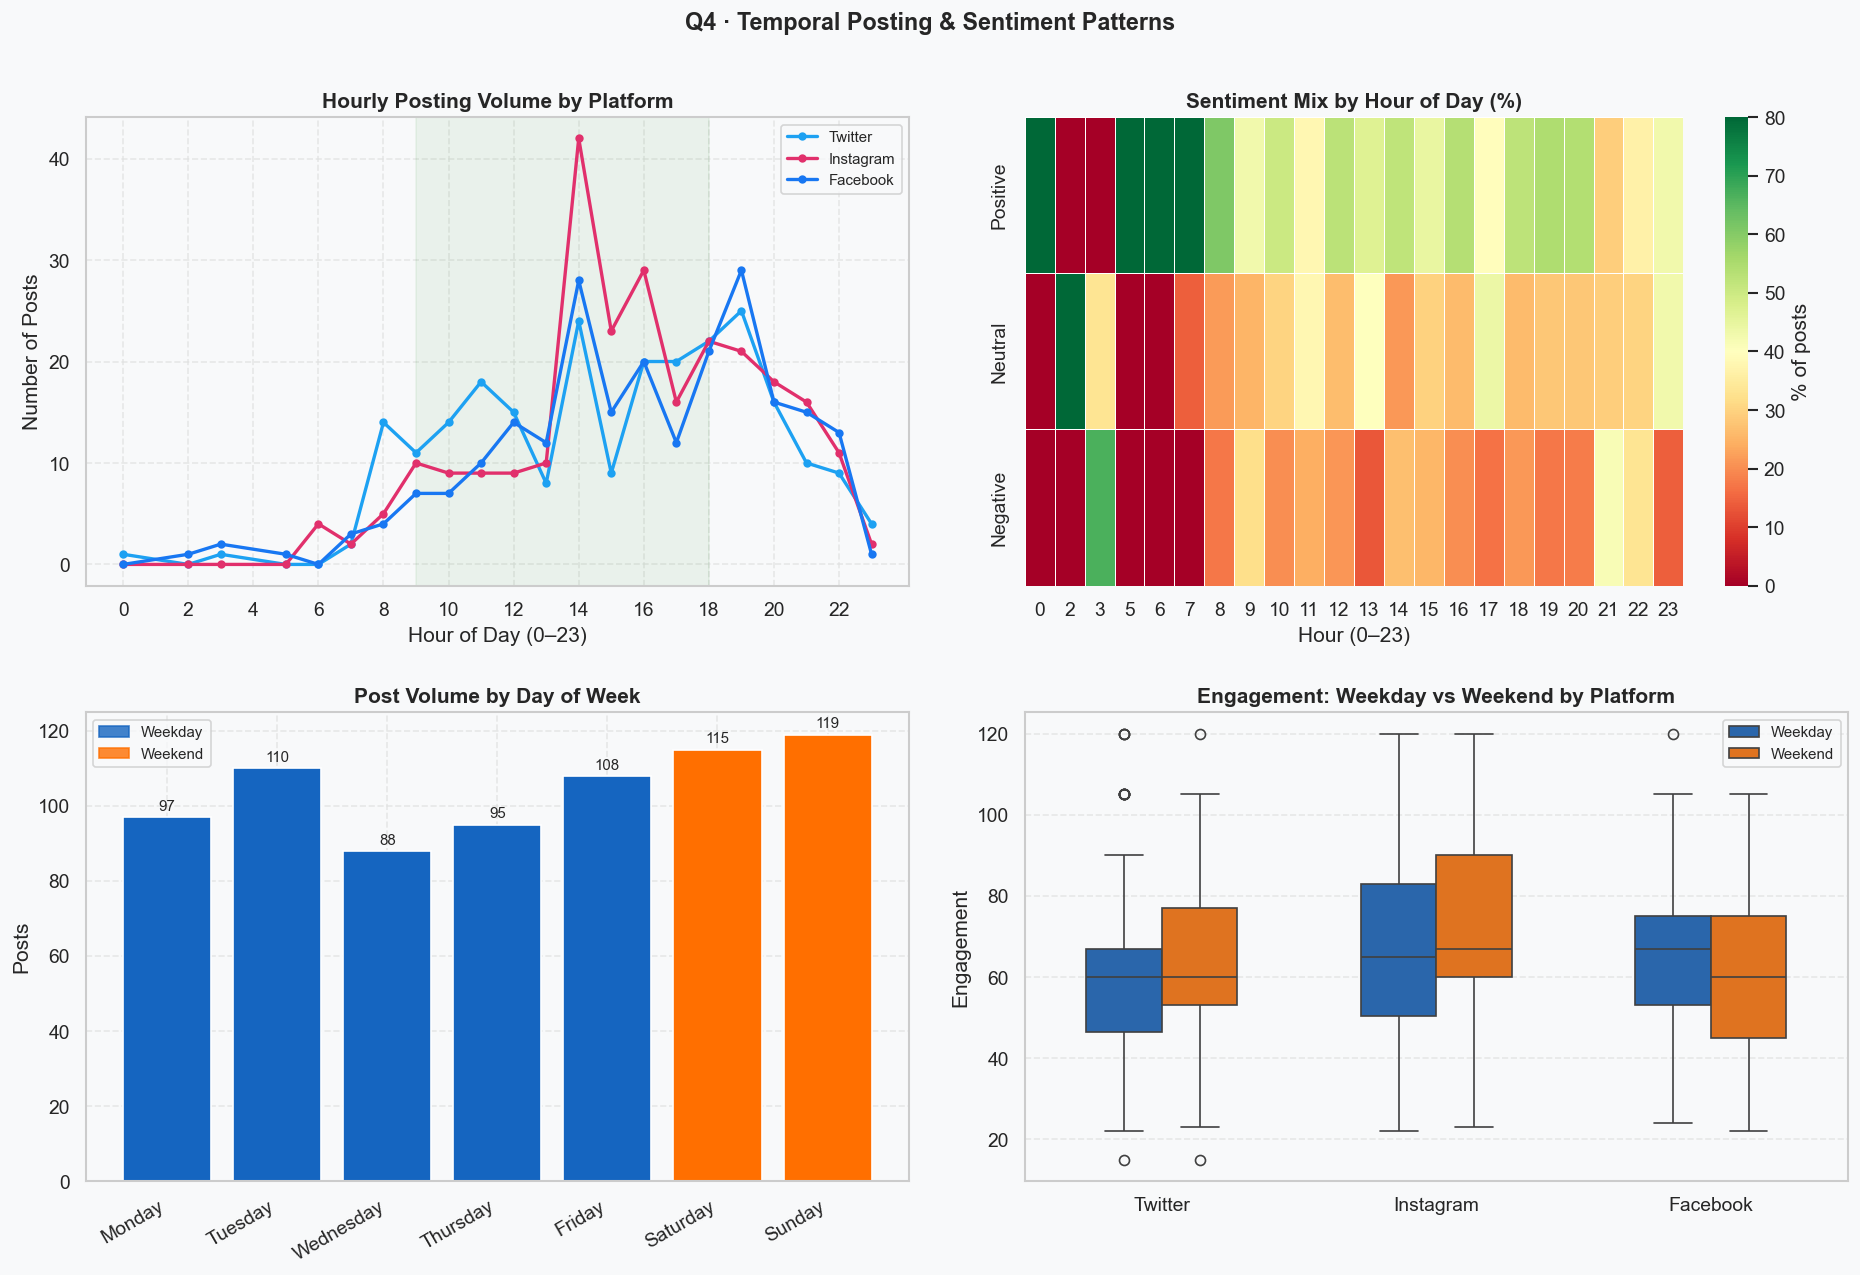

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

# ── Hourly post count ─────────────────────────────────────────────────────
ax = axes[0,0]
hourly = df.groupby(['Hour','Platform']).size().unstack(fill_value=0)
for plat, color in PLATFORM_COLORS.items():
    if plat in hourly.columns:
        ax.plot(hourly.index, hourly[plat], 'o-', color=color,
                linewidth=2, markersize=4, label=plat)
ax.set_title('Hourly Posting Volume by Platform', fontweight='bold')
ax.set_xlabel('Hour of Day (0–23)'); ax.set_ylabel('Number of Posts')
ax.set_xticks(range(0,24,2)); ax.legend(fontsize=9)
ax.axvspan(9,18, alpha=0.06, color='green', label='Business hours')

# ── Hourly sentiment heatmap ──────────────────────────────────────────────
ax2 = axes[0,1]
hour_pol = df.groupby(['Hour','polarity']).size().unstack(fill_value=0)
for c in ['Positive','Neutral','Negative']:
    if c not in hour_pol: hour_pol[c] = 0
hour_pct = hour_pol[['Positive','Neutral','Negative']].div(
    hour_pol.sum(axis=1), axis=0) * 100
sns.heatmap(hour_pct.T, annot=False, cmap='RdYlGn',
            linewidths=0.3, ax=ax2, vmin=0, vmax=80,
            cbar_kws={'label':'% of posts'})
ax2.set_title('Sentiment Mix by Hour of Day (%)', fontweight='bold')
ax2.set_xlabel('Hour (0–23)'); ax2.set_ylabel('')

# ── Day-of-week volume ────────────────────────────────────────────────────
ax3 = axes[1,0]
dow_valid = df[df['day_of_week'].isin(DOW_ORDER)]
dow_counts = dow_valid.groupby('day_of_week').size().reindex(DOW_ORDER, fill_value=0)
dow_colors = [PAL['highlight'] if d in ['Saturday','Sunday'] else PAL['neutral']
              for d in DOW_ORDER]
bars = ax3.bar(DOW_ORDER, dow_counts.values, color=dow_colors, edgecolor='white')
for bar, val in zip(bars, dow_counts.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             str(val), ha='center', va='bottom', fontsize=9)
ax3.set_title('Post Volume by Day of Week', fontweight='bold')
ax3.set_ylabel('Posts')
ax3.set_xticklabels(DOW_ORDER, rotation=30, ha='right')
weekend_patch = mpatches.Patch(color=PAL['highlight'], alpha=0.8, label='Weekend')
weekday_patch = mpatches.Patch(color=PAL['neutral'],   alpha=0.8, label='Weekday')
ax3.legend(handles=[weekday_patch, weekend_patch], fontsize=9)

# ── Engagement: weekday vs weekend ────────────────────────────────────────
ax4 = axes[1,1]
sns.boxplot(data=df, x='Platform', y='engagement',
            hue='is_weekend',
            hue_order=[False, True],
            palette={False: PAL['neutral'], True: PAL['highlight']},
            order=['Twitter','Instagram','Facebook'], ax=ax4, width=0.55)
ax4.set_title('Engagement: Weekday vs Weekend by Platform', fontweight='bold')
ax4.set_xlabel(''); ax4.set_ylabel('Engagement')
handles, labels = ax4.get_legend_handles_labels()
ax4.legend(handles, ['Weekday','Weekend'], fontsize=9)

fig.suptitle('Q4 · Temporal Posting & Sentiment Patterns',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q4_temporal_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()


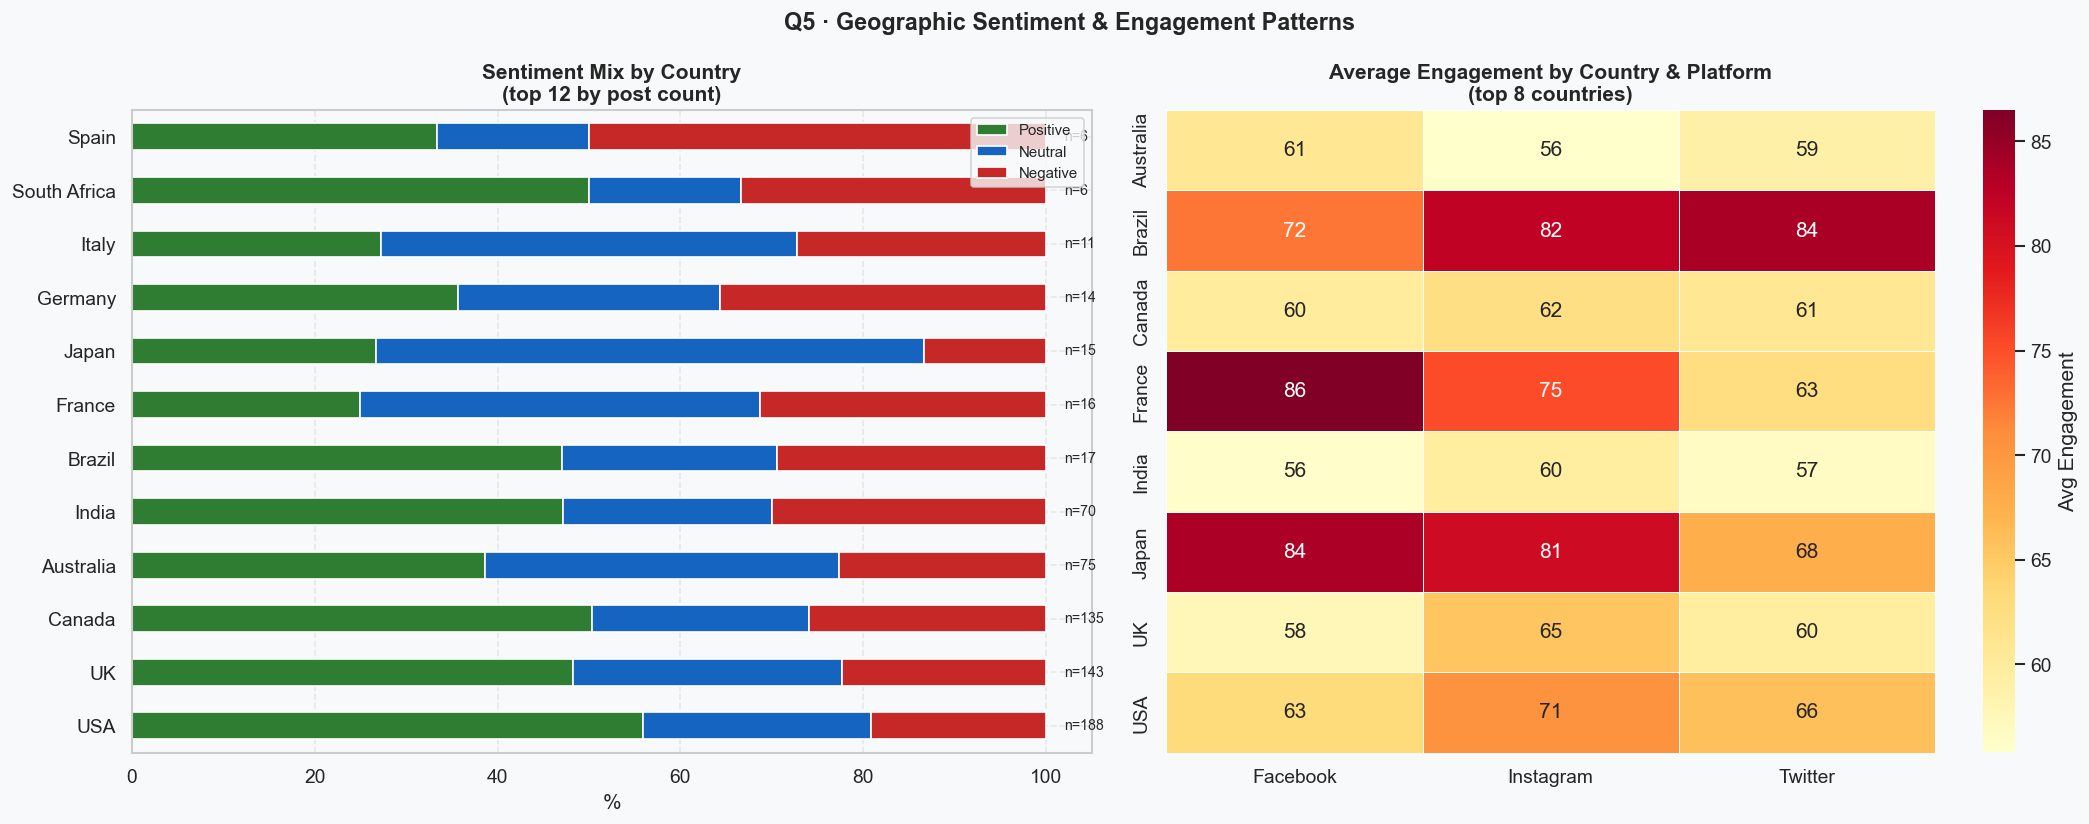


── Positive sentiment % by top country ────────────────
  USA              55.9%  ███████████  (n=188)
  Canada           50.4%  ██████████  (n=135)
  South Africa     50.0%  ██████████  (n=6)
  UK               48.3%  █████████  (n=143)
  India            47.1%  █████████  (n=70)
  Brazil           47.1%  █████████  (n=17)
  Australia        38.7%  ███████  (n=75)
  Germany          35.7%  ███████  (n=14)
  Spain            33.3%  ██████  (n=6)
  Italy            27.3%  █████  (n=11)
  Japan            26.7%  █████  (n=15)
  France           25.0%  █████  (n=16)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top countries by post count ───────────────────────────────────────────
ax = axes[0]
top_countries = df['Country'].value_counts().head(12)
country_pol = df[df['Country'].isin(top_countries.index)]\
                .groupby(['Country','polarity']).size().unstack(fill_value=0)
for c in ['Positive','Neutral','Negative']:
    if c not in country_pol: country_pol[c] = 0
country_pct = country_pol[['Positive','Neutral','Negative']].div(
    country_pol.sum(axis=1), axis=0) * 100
country_pct = country_pct.loc[top_countries.index]

country_pct.plot(kind='barh', stacked=True, ax=ax,
                 color=[PAL['positive'], PAL['neutral'], PAL['negative']],
                 edgecolor='white')
ax.set_title('Sentiment Mix by Country\n(top 12 by post count)', fontweight='bold')
ax.set_xlabel('%'); ax.set_ylabel('')
ax.legend(fontsize=9)
for i, country in enumerate(country_pct.index):
    n = top_countries[country]
    ax.text(102, i, f'n={n}', va='center', fontsize=8.5)

# ── Country engagement heatmap ────────────────────────────────────────────
ax2 = axes[1]
top8_countries = df['Country'].value_counts().head(8).index
country_plat = df[df['Country'].isin(top8_countries)]\
                 .groupby(['Country','Platform'])['engagement'].mean().unstack(fill_value=0)
sns.heatmap(country_plat, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax2, cbar_kws={'label':'Avg Engagement'})
ax2.set_title('Average Engagement by Country & Platform\n(top 8 countries)',
              fontweight='bold')
ax2.set_ylabel(''); ax2.set_xlabel('')

fig.suptitle('Q5 · Geographic Sentiment & Engagement Patterns',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q5_geographic_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\n── Positive sentiment % by top country ────────────────')
pos_pct = country_pct['Positive'].sort_values(ascending=False)
for country, pct in pos_pct.items():
    n = top_countries[country]
    bar = '█' * int(pct/5)
    print(f'  {country:<15} {pct:>5.1f}%  {bar}  (n={n})')


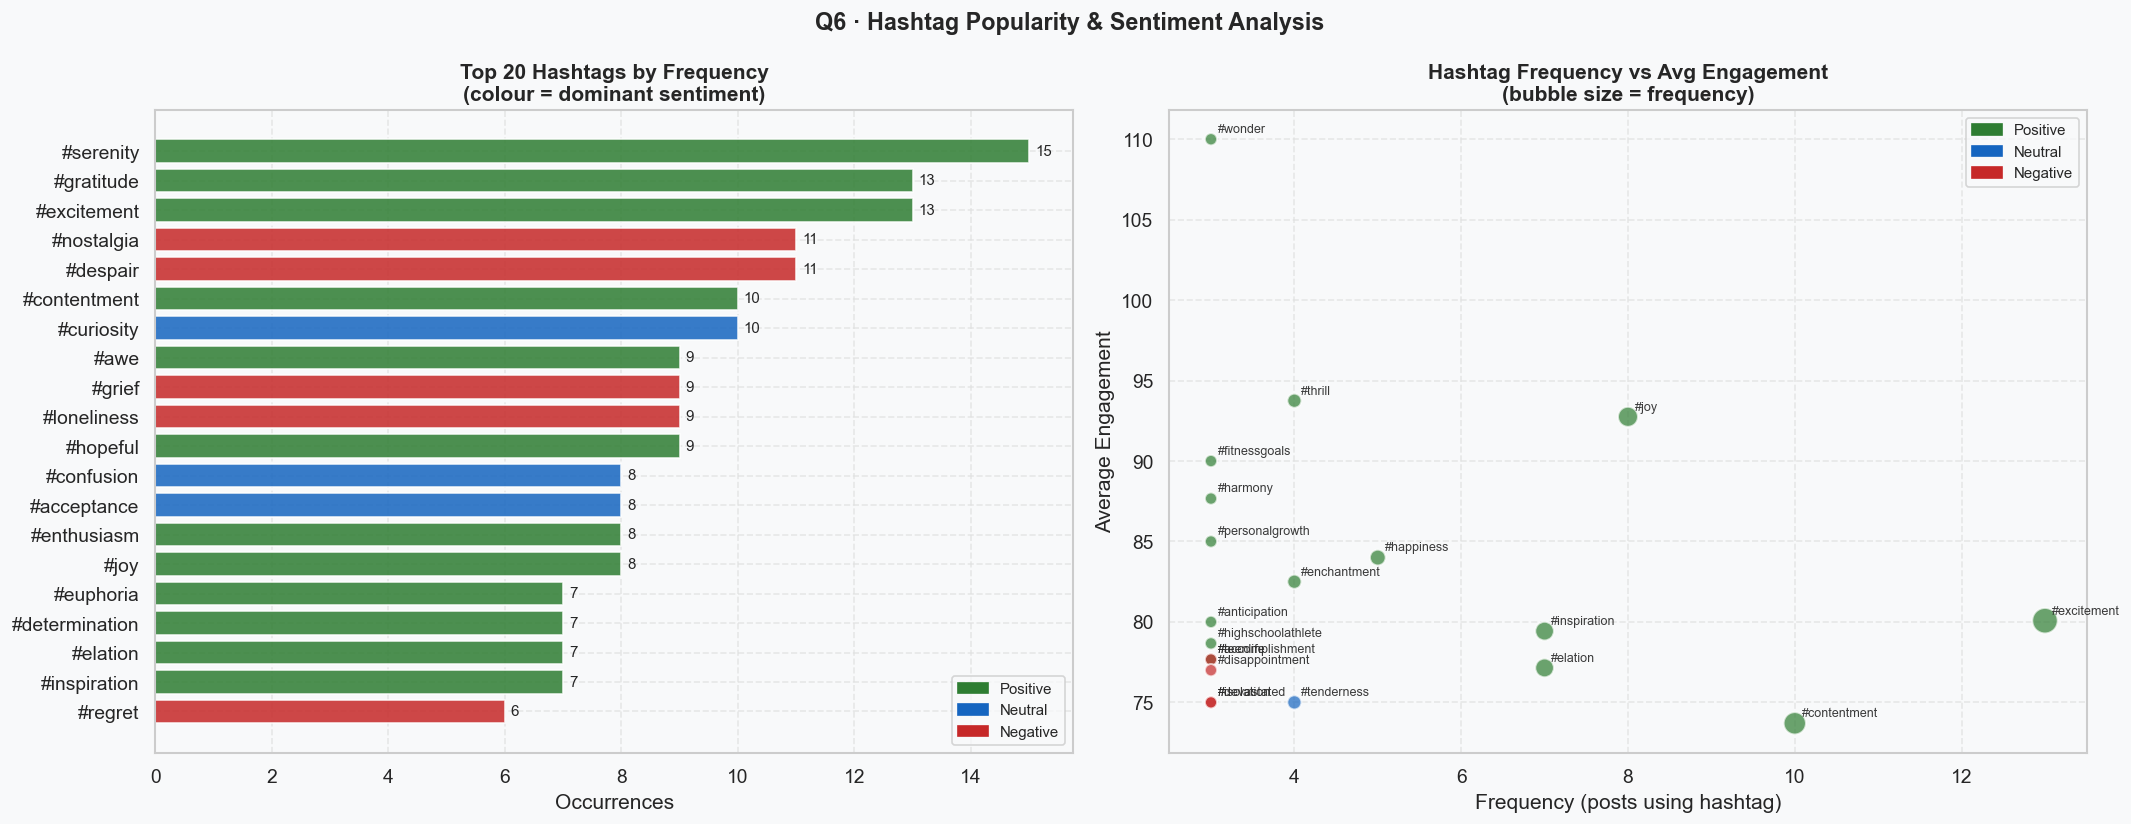

In [12]:
# Build hashtag → posts mapping
all_hashtags = []
for _, row in df.iterrows():
    for tag in row['hashtag_list']:
        all_hashtags.append({
            'hashtag'   : tag.lower(),
            'polarity'  : row['polarity'],
            'engagement': row['engagement'],
            'platform'  : row['Platform'],
        })
htdf = pd.DataFrame(all_hashtags)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Top 20 hashtags by frequency ─────────────────────────────────────────
ax = axes[0]
top_ht = htdf['hashtag'].value_counts().head(20)
ht_pol = htdf.groupby('hashtag')['polarity']\
             .apply(lambda x: x.value_counts().idxmax())
ht_colors = [PAL['positive'] if ht_pol.get(h,'Neutral')=='Positive'
             else PAL['negative'] if ht_pol.get(h,'Neutral')=='Negative'
             else PAL['neutral']
             for h in top_ht.index]
bars = ax.barh([f'#{h}' for h in top_ht.index[::-1]],
               top_ht.values[::-1],
               color=ht_colors[::-1], edgecolor='white', alpha=0.85)
for bar, val in zip(bars, top_ht.values[::-1]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_title('Top 20 Hashtags by Frequency\n(colour = dominant sentiment)',
             fontweight='bold')
ax.set_xlabel('Occurrences')
ax.legend(handles=legend_els, fontsize=9)

# ── Hashtag engagement bubble chart ──────────────────────────────────────
ax2 = axes[1]
ht_stats = (htdf.groupby('hashtag')
               .agg(count=('hashtag','count'),
                    avg_eng=('engagement','mean'))
               .query('count >= 3')
               .sort_values('avg_eng', ascending=False)
               .head(20))
ht_stats['polarity'] = ht_stats.index.map(
    lambda h: ht_pol.get(h, 'Neutral'))
colors_bubble = [PAL['positive'] if p=='Positive'
                 else PAL['negative'] if p=='Negative'
                 else PAL['neutral']
                 for p in ht_stats['polarity']]
scatter = ax2.scatter(ht_stats['count'], ht_stats['avg_eng'],
                      s=ht_stats['count']*18,
                      c=colors_bubble, alpha=0.7,
                      edgecolors='white', linewidths=1.2)
for i, (tag, row) in enumerate(ht_stats.iterrows()):
    ax2.annotate(f'#{tag}',
                 (row['count'], row['avg_eng']),
                 textcoords='offset points', xytext=(4,4),
                 fontsize=7.5, alpha=0.9)
ax2.set_xlabel('Frequency (posts using hashtag)')
ax2.set_ylabel('Average Engagement')
ax2.set_title('Hashtag Frequency vs Avg Engagement\n(bubble size = frequency)',
              fontweight='bold')
ax2.legend(handles=legend_els, fontsize=9)

fig.suptitle('Q6 · Hashtag Popularity & Sentiment Analysis',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q6_hashtag_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()


### Q7 · How has sentiment trended year-over-year (2010–2023)?
**Insight:** A rising negative sentiment trend year-on-year could indicate increasing
platform toxicity or societal stress — actionable for platform policy teams.


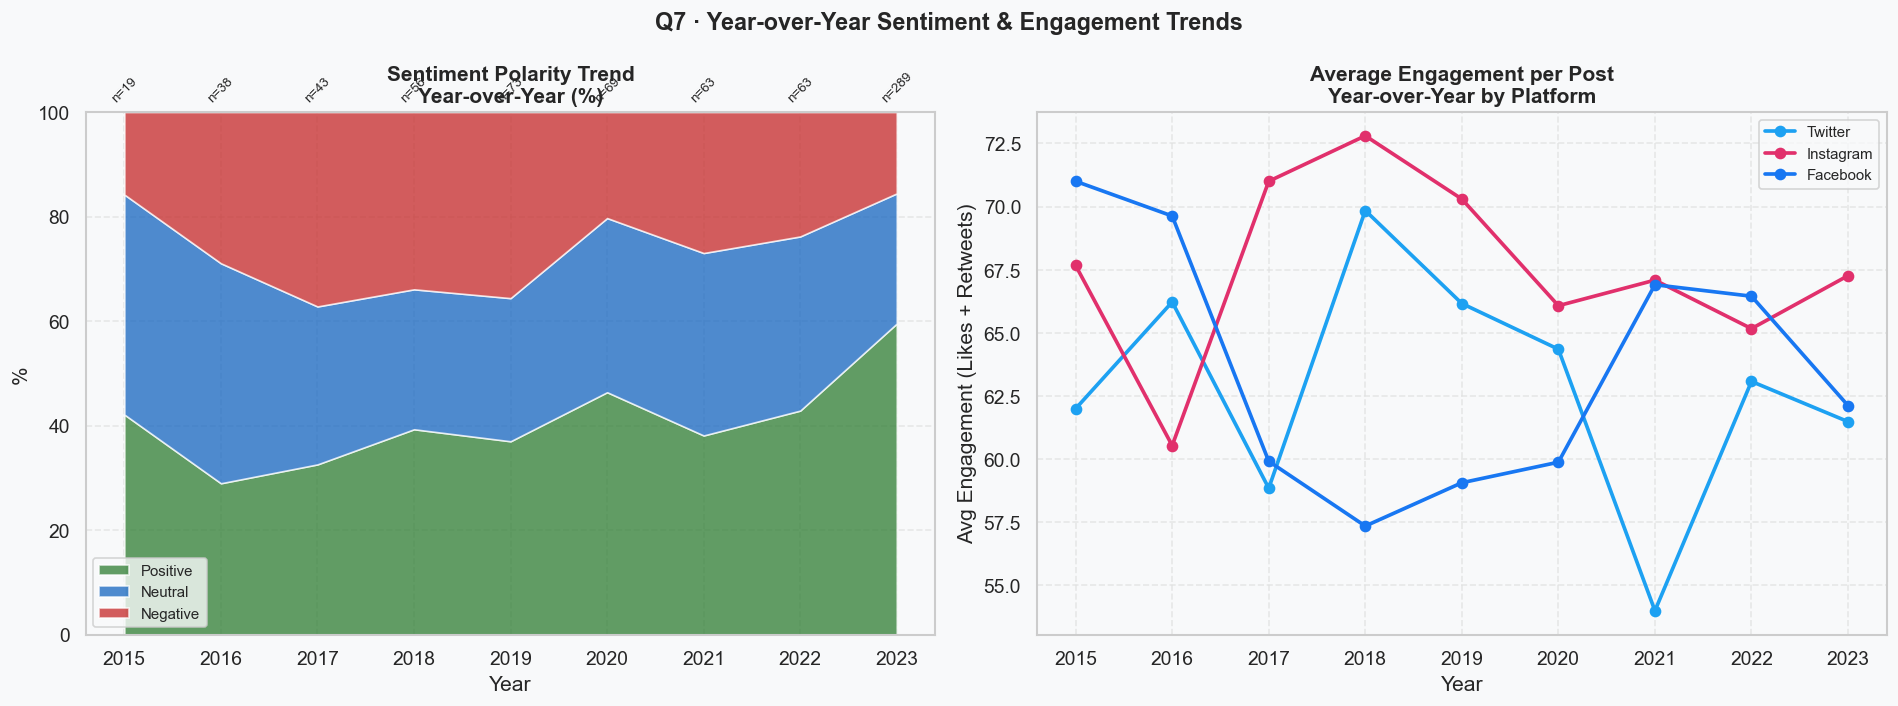

In [13]:
df_years = df[df['Year'] >= 2015].copy()   # focus on years with meaningful volume

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Stacked area: polarity % by year ─────────────────────────────────────
ax = axes[0]
yoy_pol = df_years.groupby(['Year','polarity']).size().unstack(fill_value=0)
for c in ['Positive','Neutral','Negative']:
    if c not in yoy_pol: yoy_pol[c] = 0
yoy_pct = yoy_pol[['Positive','Neutral','Negative']].div(
    yoy_pol.sum(axis=1), axis=0) * 100
ax.stackplot(yoy_pct.index,
             yoy_pct['Positive'], yoy_pct['Neutral'], yoy_pct['Negative'],
             labels=['Positive','Neutral','Negative'],
             colors=[PAL['positive'], PAL['neutral'], PAL['negative']],
             alpha=0.75)
ax.set_title('Sentiment Polarity Trend\nYear-over-Year (%)', fontweight='bold')
ax.set_ylabel('%'); ax.set_xlabel('Year')
ax.legend(loc='lower left', fontsize=9)
ax.set_ylim(0, 100)
for yr in yoy_pct.index:
    n = len(df_years[df_years['Year']==yr])
    ax.text(yr, 102, f'n={n}', ha='center', fontsize=8, rotation=45)

# ── YoY average engagement ────────────────────────────────────────────────
ax2 = axes[1]
yoy_eng = df_years.groupby(['Year','Platform'])['engagement'].mean().unstack()
for plat, color in PLATFORM_COLORS.items():
    if plat in yoy_eng.columns:
        ax2.plot(yoy_eng.index, yoy_eng[plat], 'o-',
                 color=color, linewidth=2.2, markersize=6, label=plat)
ax2.set_title('Average Engagement per Post\nYear-over-Year by Platform',
              fontweight='bold')
ax2.set_ylabel('Avg Engagement (Likes + Retweets)')
ax2.set_xlabel('Year')
ax2.legend(fontsize=9)

fig.suptitle('Q7 · Year-over-Year Sentiment & Engagement Trends',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q7_yoy_trends.png'),
            dpi=150, bbox_inches='tight')
plt.show()


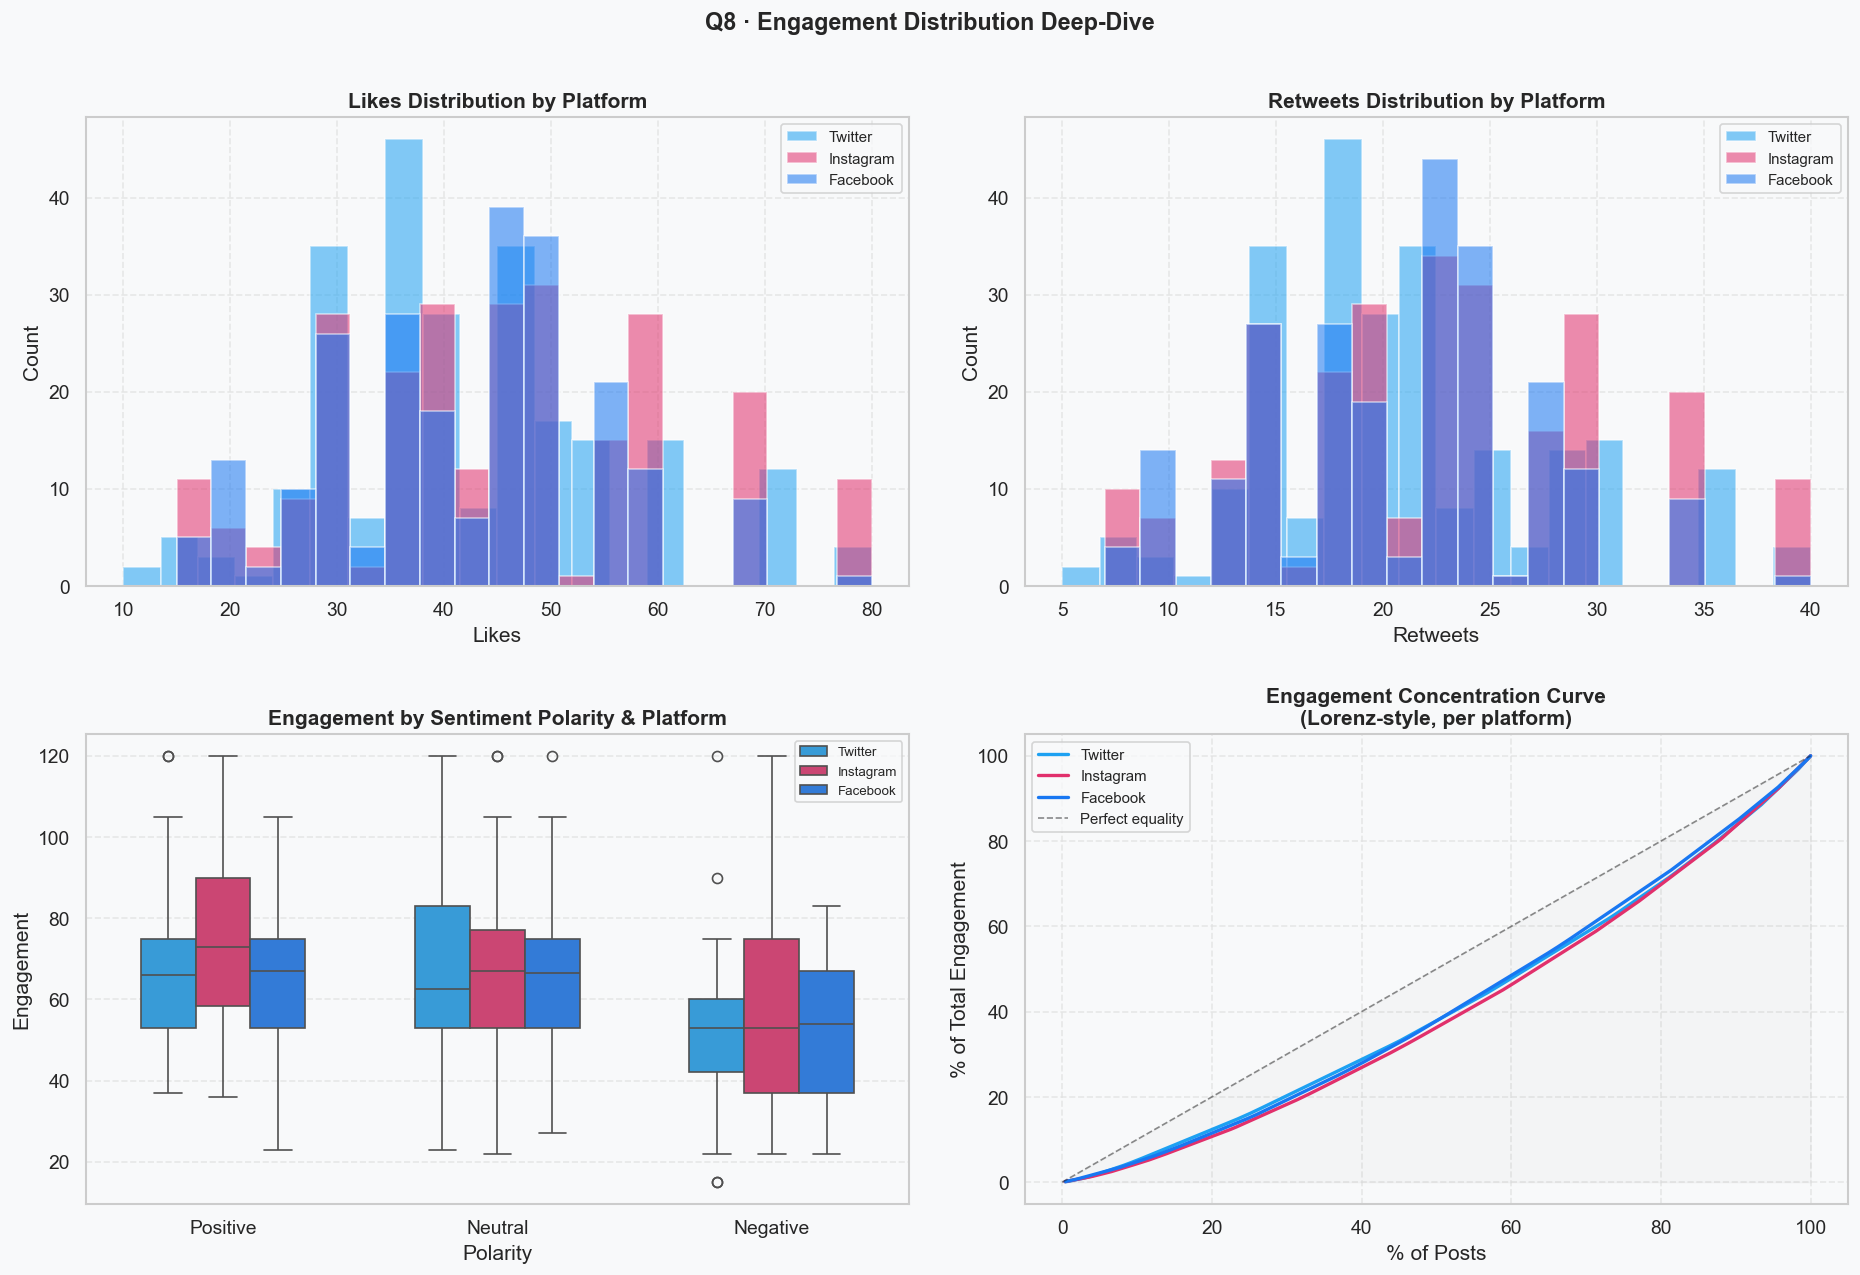

── Engagement percentiles by platform ─────────────────────
  Twitter     : p25=51  p50=60  p75=75  p90=90  max=120
  Instagram   : p25=53  p50=67  p75=83  p90=105  max=120
  Facebook    : p25=48  p50=67  p75=75  p90=83  max=120


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# ── Likes distribution by platform ───────────────────────────────────────
ax = axes[0,0]
for plat, color in PLATFORM_COLORS.items():
    sub = df[df['Platform']==plat]['Likes']
    ax.hist(sub, bins=20, alpha=0.55, color=color, label=plat, edgecolor='white')
ax.set_title('Likes Distribution by Platform', fontweight='bold')
ax.set_xlabel('Likes'); ax.set_ylabel('Count'); ax.legend(fontsize=9)

# ── Retweets distribution ─────────────────────────────────────────────────
ax2 = axes[0,1]
for plat, color in PLATFORM_COLORS.items():
    sub = df[df['Platform']==plat]['Retweets']
    ax2.hist(sub, bins=20, alpha=0.55, color=color, label=plat, edgecolor='white')
ax2.set_title('Retweets Distribution by Platform', fontweight='bold')
ax2.set_xlabel('Retweets'); ax2.set_ylabel('Count'); ax2.legend(fontsize=9)

# ── Engagement by polarity × platform ────────────────────────────────────
ax3 = axes[1,0]
sns.boxplot(data=df, x='polarity', y='engagement',
            hue='Platform',
            hue_order=['Twitter','Instagram','Facebook'],
            order=['Positive','Neutral','Negative'],
            palette=PLATFORM_COLORS, ax=ax3, width=0.6)
ax3.set_title('Engagement by Sentiment Polarity & Platform',
              fontweight='bold')
ax3.set_xlabel('Polarity'); ax3.set_ylabel('Engagement')
ax3.legend(fontsize=8)

# ── Cumulative engagement Lorenz-style curve ─────────────────────────────
ax4 = axes[1,1]
for plat, color in PLATFORM_COLORS.items():
    sub_eng = df[df['Platform']==plat]['engagement'].sort_values().values
    cum_pct_posts = np.arange(1, len(sub_eng)+1) / len(sub_eng) * 100
    cum_pct_eng   = np.cumsum(sub_eng) / sub_eng.sum() * 100
    ax4.plot(cum_pct_posts, cum_pct_eng, color=color, linewidth=2, label=plat)
ax4.plot([0,100],[0,100],'k--', linewidth=1, alpha=0.5, label='Perfect equality')
ax4.set_title('Engagement Concentration Curve\n(Lorenz-style, per platform)',
              fontweight='bold')
ax4.set_xlabel('% of Posts'); ax4.set_ylabel('% of Total Engagement')
ax4.legend(fontsize=9)
ax4.fill_between([0,100],[0,100], alpha=0.04, color='grey')

fig.suptitle('Q8 · Engagement Distribution Deep-Dive',
             fontweight='bold', fontsize=14)
fig.tight_layout(pad=2)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q8_engagement_distribution.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('── Engagement percentiles by platform ─────────────────────')
for plat in ['Twitter','Instagram','Facebook']:
    sub = df[df['Platform']==plat]['engagement']
    print(f'  {plat:<12}: '
          f'p25={sub.quantile(.25):.0f}  '
          f'p50={sub.quantile(.50):.0f}  '
          f'p75={sub.quantile(.75):.0f}  '
          f'p90={sub.quantile(.90):.0f}  '
          f'max={sub.max():.0f}')


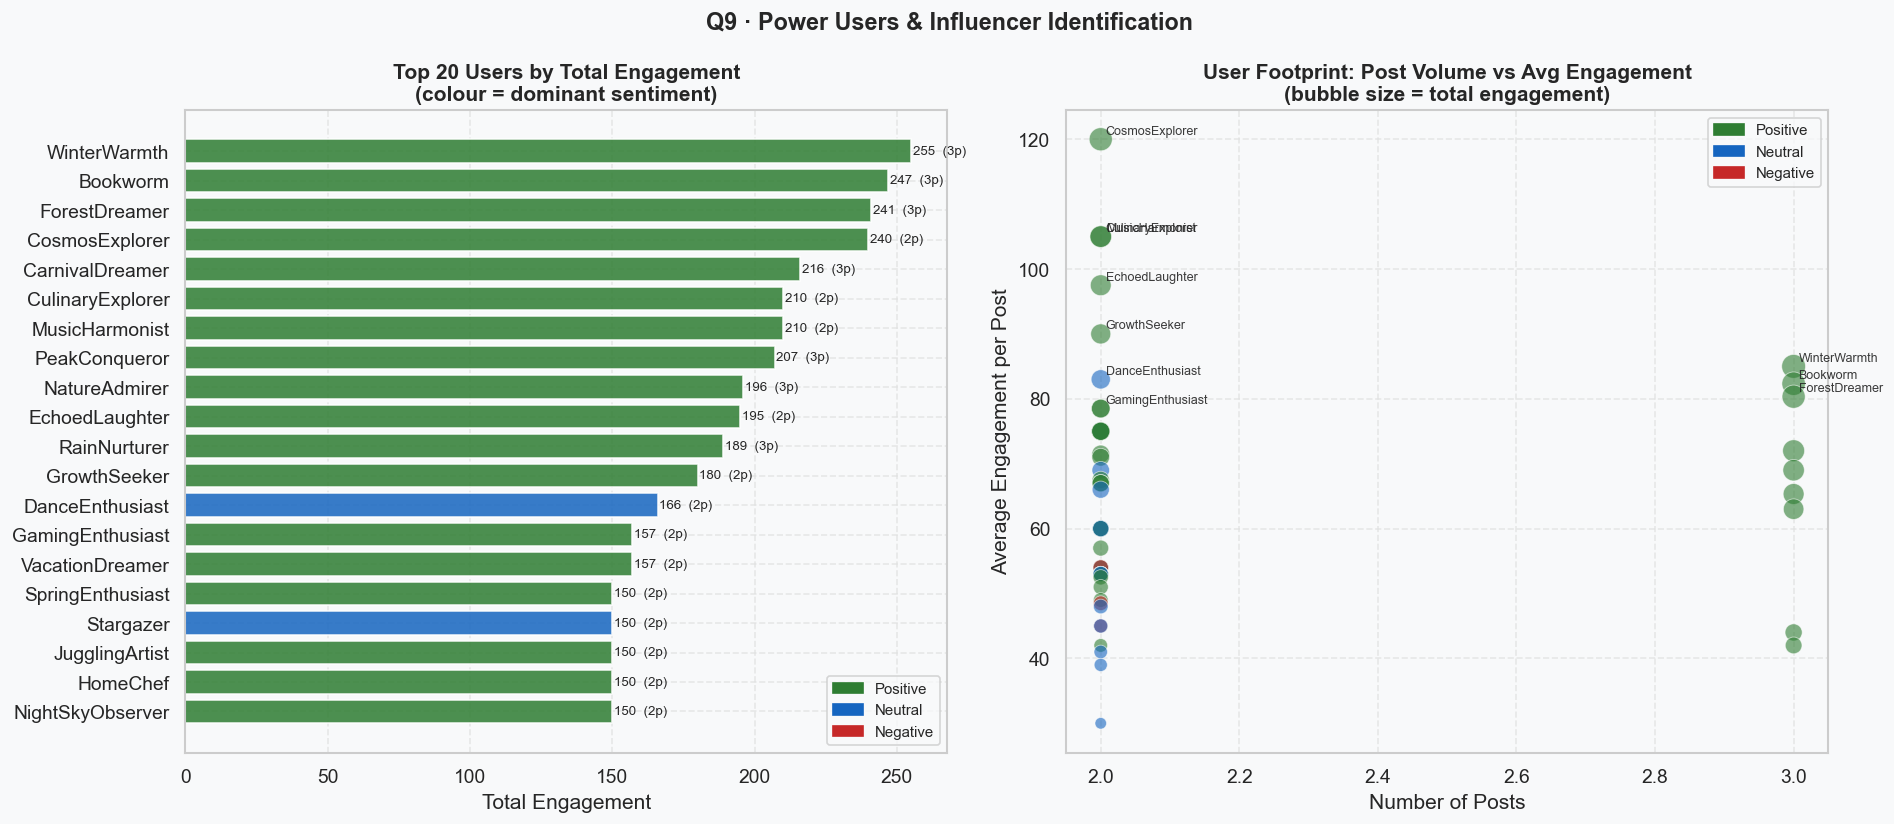


── Top 10 Users by Total Engagement ──────────────────────────
            User  posts  total_eng    avg_eng          platforms top_polarity
    WinterWarmth      3      255.0  85.000000 Instagram, Twitter     Positive
        Bookworm      3      247.0  82.333333 Instagram, Twitter     Positive
   ForestDreamer      3      241.0  80.333333           Facebook     Positive
  CosmosExplorer      2      240.0 120.000000          Instagram     Positive
 CarnivalDreamer      3      216.0  72.000000           Facebook     Positive
CulinaryExplorer      2      210.0 105.000000            Twitter     Positive
  MusicHarmonist      2      210.0 105.000000          Instagram     Positive
   PeakConqueror      3      207.0  69.000000            Twitter     Positive
   NatureAdmirer      3      196.0  65.333333 Instagram, Twitter     Positive
  EchoedLaughter      2      195.0  97.500000 Instagram, Twitter     Positive


In [15]:
user_stats = (df.groupby('User')
                .agg(
                    posts      = ('Text',       'count'),
                    total_eng  = ('engagement', 'sum'),
                    avg_eng    = ('engagement', 'mean'),
                    avg_likes  = ('Likes',      'mean'),
                    avg_rt     = ('Retweets',   'mean'),
                    platforms  = ('Platform',   lambda x: ', '.join(sorted(x.unique()))),
                    top_polarity = ('polarity', lambda x: x.value_counts().idxmax()),
                )
                .sort_values('total_eng', ascending=False)
                .reset_index()
             )

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Top 20 users by total engagement ─────────────────────────────────────
ax = axes[0]
top_users = user_stats.head(20)
u_colors  = [PAL['positive'] if p=='Positive'
             else PAL['negative'] if p=='Negative'
             else PAL['neutral']
             for p in top_users['top_polarity']]
bars = ax.barh(top_users['User'][::-1], top_users['total_eng'][::-1],
               color=u_colors[::-1], edgecolor='white', alpha=0.85)
for bar, val, posts in zip(bars,
                            top_users['total_eng'][::-1],
                            top_users['posts'][::-1]):
    ax.text(bar.get_width()+0.5,
            bar.get_y()+bar.get_height()/2,
            f'{val:.0f}  ({posts}p)', va='center', fontsize=8)
ax.set_title('Top 20 Users by Total Engagement\n(colour = dominant sentiment)',
             fontweight='bold')
ax.set_xlabel('Total Engagement')
ax.legend(handles=legend_els, fontsize=9)

# ── Posts vs avg_engagement scatter ──────────────────────────────────────
ax2 = axes[1]
multi_post = user_stats[user_stats['posts'] >= 2]
pol_colors_user = [PAL['positive'] if p=='Positive'
                   else PAL['negative'] if p=='Negative'
                   else PAL['neutral']
                   for p in multi_post['top_polarity']]
ax2.scatter(multi_post['posts'], multi_post['avg_eng'],
            c=pol_colors_user, s=multi_post['total_eng']*0.8,
            alpha=0.6, edgecolors='white', linewidths=0.5)
# Label top 10
for _, row in multi_post.nlargest(10,'avg_eng').iterrows():
    ax2.annotate(row['User'],
                 (row['posts'], row['avg_eng']),
                 fontsize=7.5, xytext=(3,3),
                 textcoords='offset points', alpha=0.9)
ax2.set_xlabel('Number of Posts')
ax2.set_ylabel('Average Engagement per Post')
ax2.set_title('User Footprint: Post Volume vs Avg Engagement\n(bubble size = total engagement)',
              fontweight='bold')
ax2.legend(handles=legend_els, fontsize=9)

fig.suptitle('Q9 · Power Users & Influencer Identification',
             fontweight='bold', fontsize=14)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q9_power_users.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('\n── Top 10 Users by Total Engagement ──────────────────────────')
print(user_stats[['User','posts','total_eng','avg_eng','platforms','top_polarity']]
      .head(10).to_string(index=False))


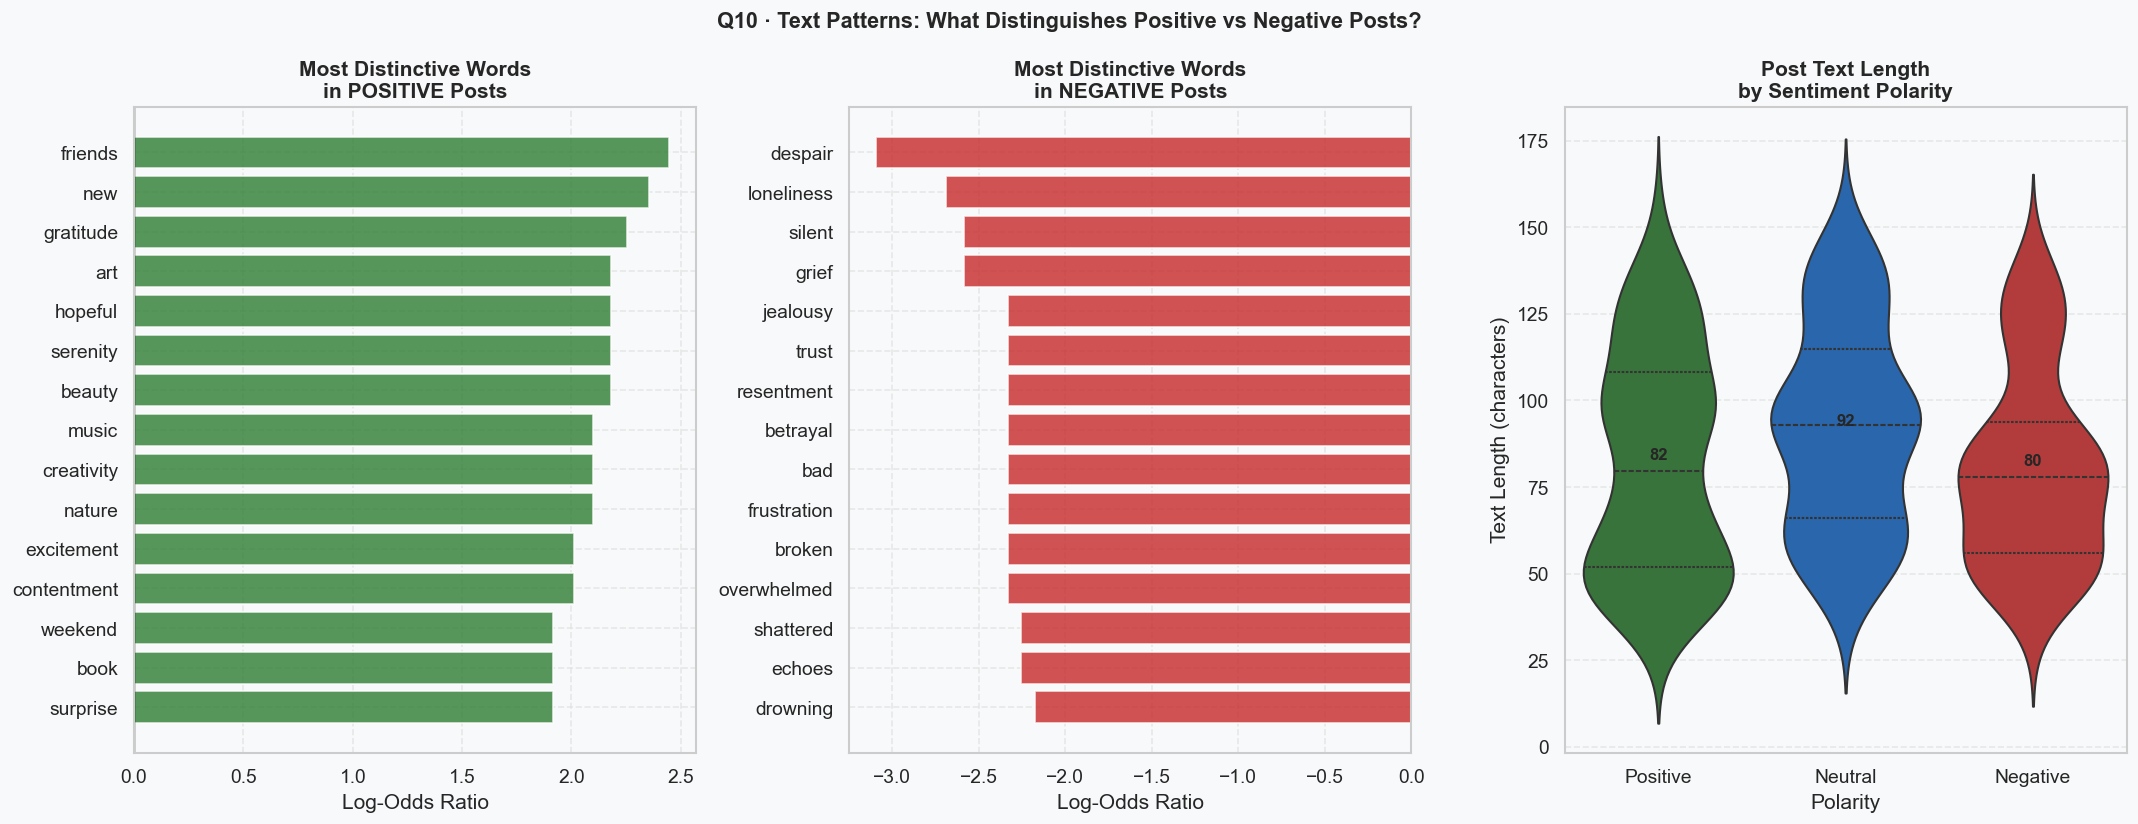

Top 10 positive-signal words:
  friends              log-odds=2.448
  new                  log-odds=2.355
  gratitude            log-odds=2.254
  art                  log-odds=2.180
  hopeful              log-odds=2.180
  serenity             log-odds=2.180
  beauty               log-odds=2.180
  music                log-odds=2.100
  creativity           log-odds=2.100
  nature               log-odds=2.100

Top 10 negative-signal words:
  despair              log-odds=-3.093
  loneliness           log-odds=-2.688
  silent               log-odds=-2.583
  grief                log-odds=-2.583
  jealousy             log-odds=-2.331
  trust                log-odds=-2.331
  resentment           log-odds=-2.331
  betrayal             log-odds=-2.331
  bad                  log-odds=-2.331
  frustration          log-odds=-2.331


In [16]:
import string

STOPWORDS = {
    'i','me','my','myself','we','our','you','your','he','she','it','its',
    'the','a','an','and','but','or','so','in','on','at','to','for','of',
    'with','is','are','was','were','be','been','being','have','has','had',
    'do','does','did','will','would','could','should','may','might','shall',
    'this','that','these','those','am','not','just','about','up','out',
    'from','by','as','into','through','after','before','all','very','too',
    'more','most','some','any','each','few','than','then','so','yet',
    'both','because','while','although','though','since','until','even',
    'what','when','where','who','which','how','if','no','nor','own',
}

def clean_tokens(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = text.translate(str.maketrans('','',string.punctuation))
    return [w for w in text.split()
            if w not in STOPWORDS and len(w) > 2 and not w.isdigit()]

pos_tokens = []
neg_tokens = []
for _, row in df.iterrows():
    toks = clean_tokens(row['Text'])
    if row['polarity'] == 'Positive': pos_tokens.extend(toks)
    elif row['polarity'] == 'Negative': neg_tokens.extend(toks)

pos_freq = Counter(pos_tokens)
neg_freq = Counter(neg_tokens)
total_pos = len(pos_tokens)
total_neg = len(neg_tokens)

# Log-odds ratio — words much more common in one class than the other
all_words = set(pos_freq.keys()) | set(neg_freq.keys())
log_odds = {}
for w in all_words:
    pf = (pos_freq.get(w, 0) + 1) / (total_pos + len(all_words))
    nf = (neg_freq.get(w, 0) + 1) / (total_neg + len(all_words))
    log_odds[w] = np.log(pf / nf)

top_pos_words = sorted(log_odds.items(), key=lambda x: -x[1])[:15]
top_neg_words = sorted(log_odds.items(), key=lambda x:  x[1])[:15]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── Positive distinctive words ────────────────────────────────────────────
ax = axes[0]
w_pos = [w for w,_ in top_pos_words]
v_pos = [v for _,v in top_pos_words]
ax.barh(w_pos[::-1], v_pos[::-1], color=PAL['positive'], edgecolor='white', alpha=0.8)
ax.set_title('Most Distinctive Words\nin POSITIVE Posts', fontweight='bold')
ax.set_xlabel('Log-Odds Ratio')
ax.axvline(0, color='black', linewidth=0.8)

# ── Negative distinctive words ────────────────────────────────────────────
ax2 = axes[1]
w_neg = [w for w,_ in top_neg_words]
v_neg = [v for _,v in top_neg_words]
ax2.barh(w_neg[::-1], v_neg[::-1], color=PAL['negative'], edgecolor='white', alpha=0.8)
ax2.set_title('Most Distinctive Words\nin NEGATIVE Posts', fontweight='bold')
ax2.set_xlabel('Log-Odds Ratio')
ax2.axvline(0, color='black', linewidth=0.8)

# ── Text length by polarity ───────────────────────────────────────────────
ax3 = axes[2]
sns.violinplot(data=df, x='polarity', y='text_length',
               order=['Positive','Neutral','Negative'],
               palette={'Positive':PAL['positive'],
                        'Neutral':PAL['neutral'],
                        'Negative':PAL['negative']},
               ax=ax3, inner='quartile')
for i, pol in enumerate(['Positive','Neutral','Negative']):
    m = df[df['polarity']==pol]['text_length'].mean()
    ax3.text(i, m+1, f'{m:.0f}', ha='center', fontsize=10, fontweight='bold')
ax3.set_title('Post Text Length\nby Sentiment Polarity', fontweight='bold')
ax3.set_xlabel('Polarity'); ax3.set_ylabel('Text Length (characters)')

fig.suptitle('Q10 · Text Patterns: What Distinguishes Positive vs Negative Posts?',
             fontweight='bold', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR,'figures','q10_text_patterns.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 positive-signal words:')
for w, s in top_pos_words[:10]: print(f'  {w:<20} log-odds={s:.3f}')
print('\nTop 10 negative-signal words:')
for w, s in top_neg_words[:10]: print(f'  {w:<20} log-odds={s:.3f}')


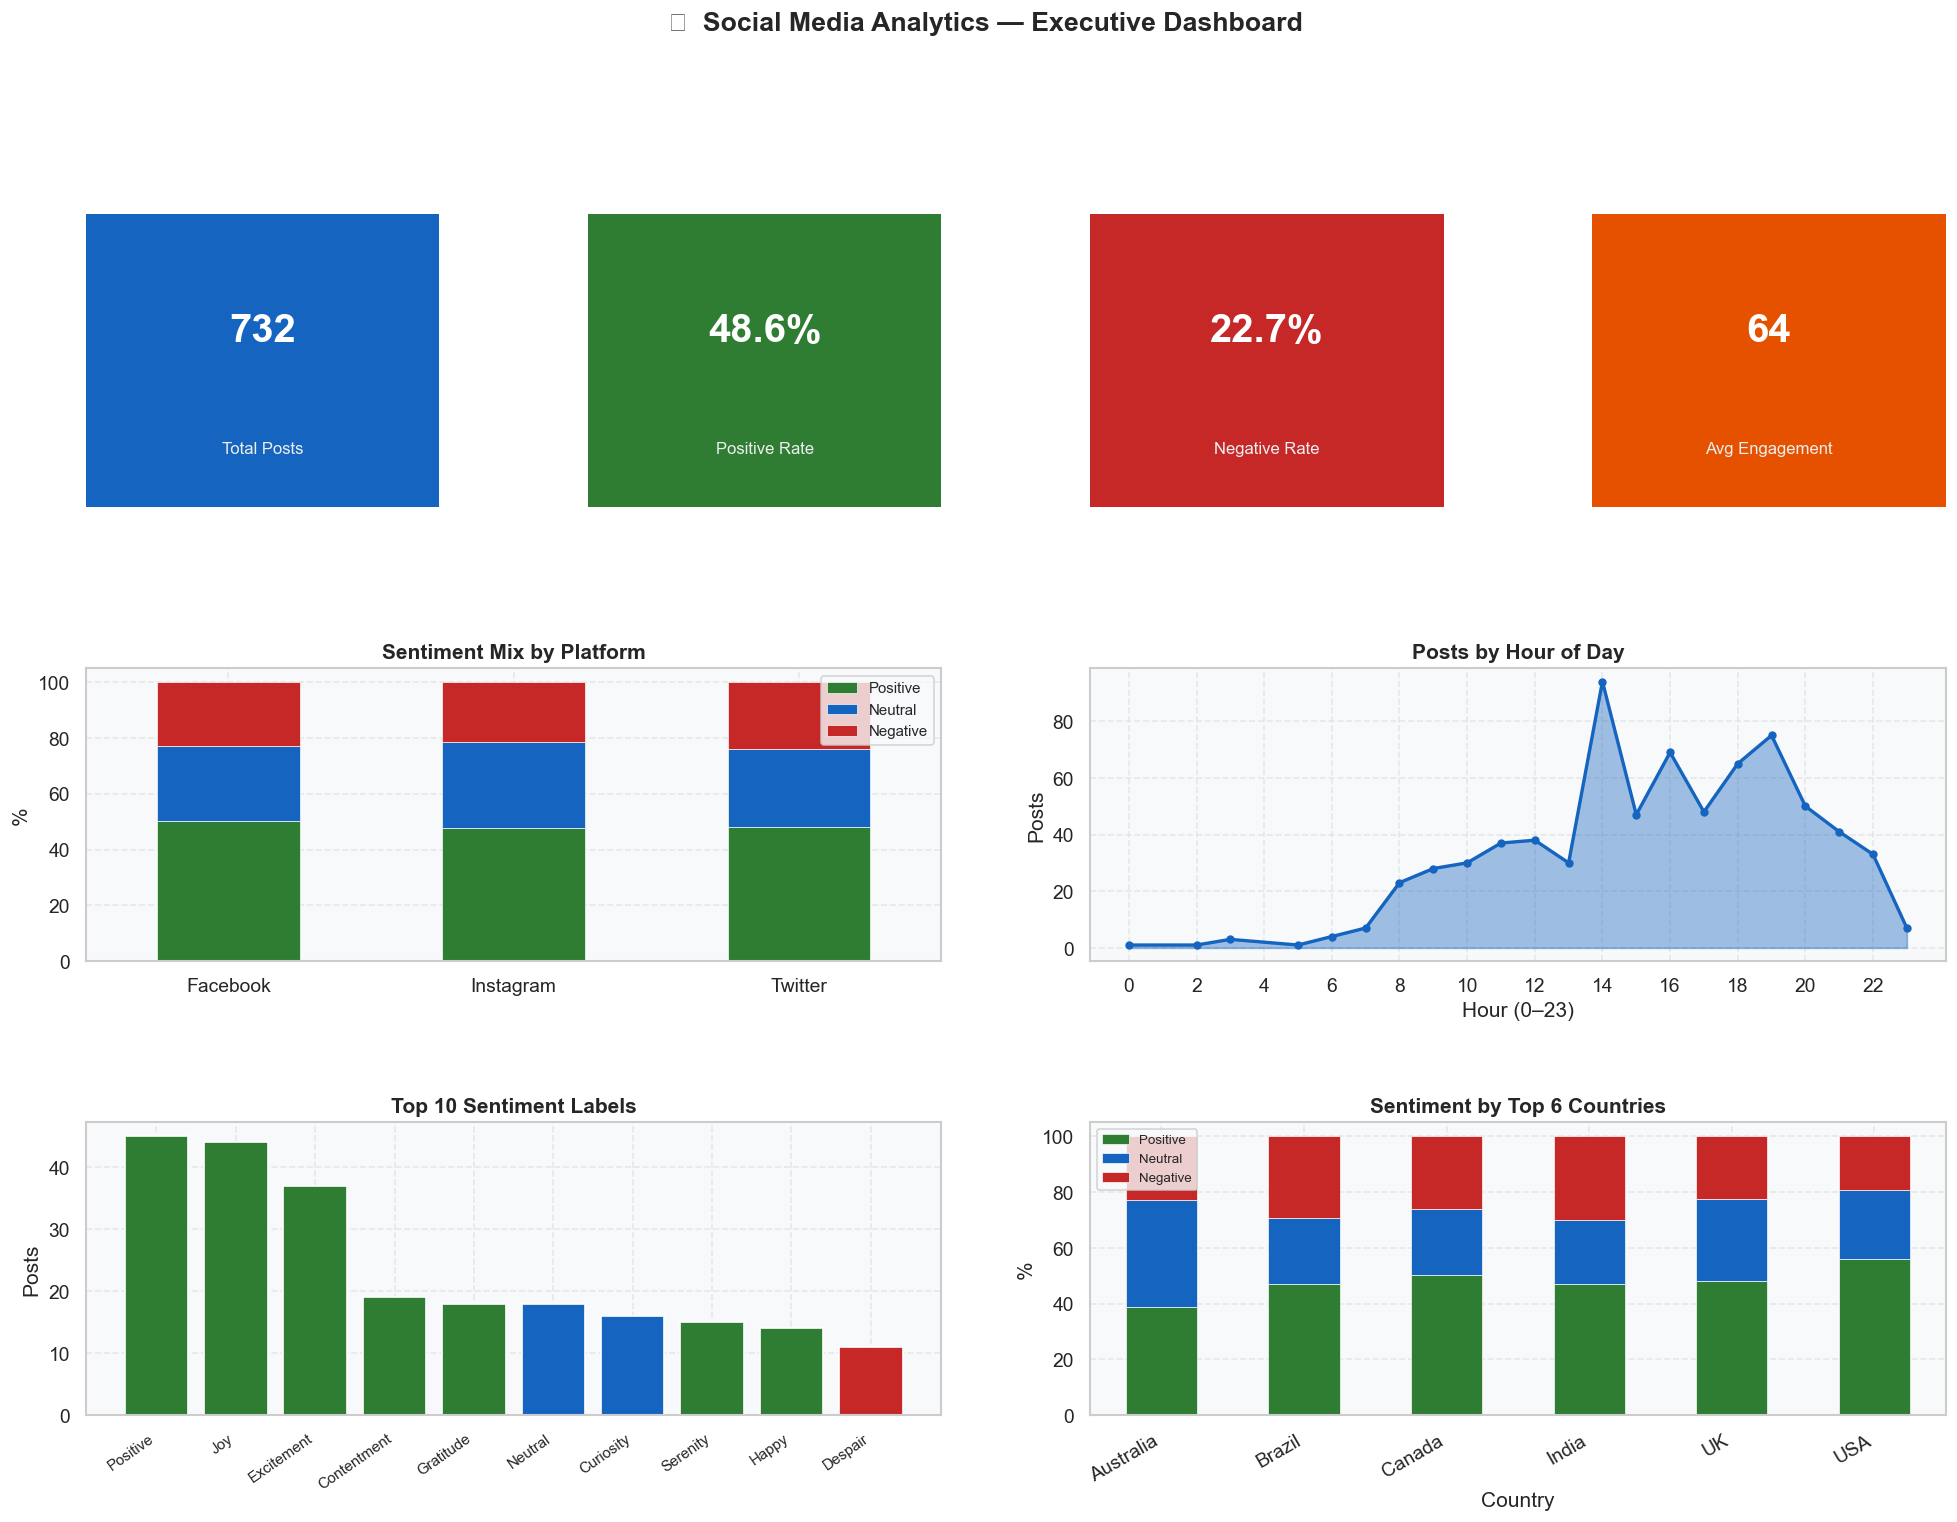

In [17]:
fig = plt.figure(figsize=(20, 13))
fig.patch.set_facecolor('#FFFFFF')
gs  = fig.add_gridspec(3, 4, hspace=0.55, wspace=0.42)

# ── KPI Tiles ─────────────────────────────────────────────────────────────
pos_pct_kpi = (df['polarity']=='Positive').mean()*100
neg_pct_kpi = (df['polarity']=='Negative').mean()*100
avg_eng_kpi = df['engagement'].mean()
top_plat    = df['Platform'].value_counts().idxmax()

kpis = [
    ('Total Posts',       f'{len(df):,}',            '#1565C0'),
    ('Positive Rate',     f'{pos_pct_kpi:.1f}%',     '#2E7D32'),
    ('Negative Rate',     f'{neg_pct_kpi:.1f}%',     '#C62828'),
    ('Avg Engagement',    f'{avg_eng_kpi:.0f}',       '#E65100'),
]
for i, (label, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, val,   ha='center', va='center', fontsize=24,
            fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(0.5, 0.20, label, ha='center', va='center', fontsize=10,
            color='#EEEEEE', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)

# ── Platform polarity mix ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
plat_pct.plot(kind='bar', stacked=True, ax=ax1,
              color=[PAL['positive'], PAL['neutral'], PAL['negative']],
              edgecolor='white', linewidth=0.4)
ax1.set_title('Sentiment Mix by Platform', fontweight='bold')
ax1.set_ylabel('%'); ax1.set_xlabel('')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.legend(fontsize=9)

# ── Hourly activity ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 2:4])
hourly_total = df.groupby('Hour').size()
ax2.fill_between(hourly_total.index, hourly_total.values,
                 alpha=0.4, color=PAL['neutral'])
ax2.plot(hourly_total.index, hourly_total.values, 'o-',
         color=PAL['neutral'], linewidth=2, markersize=4)
ax2.set_title('Posts by Hour of Day', fontweight='bold')
ax2.set_xlabel('Hour (0–23)'); ax2.set_ylabel('Posts')
ax2.set_xticks(range(0,24,2))

# ── Top 10 sentiments ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0:2])
top10_s = df['Sentiment'].value_counts().head(10)
t10_colors = [PAL['positive'] if map_polarity(s)=='Positive'
              else PAL['negative'] if map_polarity(s)=='Negative'
              else PAL['neutral']
              for s in top10_s.index]
ax3.bar(top10_s.index, top10_s.values, color=t10_colors, edgecolor='white')
ax3.set_title('Top 10 Sentiment Labels', fontweight='bold')
ax3.set_xticklabels(top10_s.index, rotation=35, ha='right', fontsize=9)
ax3.set_ylabel('Posts')

# ── Country polarity ─────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 2:4])
top6c = df['Country'].value_counts().head(6).index
c6_pol = df[df['Country'].isin(top6c)]\
           .groupby(['Country','polarity']).size().unstack(fill_value=0)
for c in ['Positive','Neutral','Negative']:
    if c not in c6_pol: c6_pol[c] = 0
c6_pct = c6_pol[['Positive','Neutral','Negative']].div(c6_pol.sum(axis=1),axis=0)*100
c6_pct.plot(kind='bar', stacked=True, ax=ax4,
            color=[PAL['positive'],PAL['neutral'],PAL['negative']],
            edgecolor='white', linewidth=0.4)
ax4.set_title('Sentiment by Top 6 Countries', fontweight='bold')
ax4.set_ylabel('%')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha='right')
ax4.legend(fontsize=8)

fig.suptitle('📱  Social Media Analytics — Executive Dashboard',
             fontsize=16, fontweight='bold', y=1.01)
fig.savefig(os.path.join(OUTPUT_DIR,'figures','dashboard.png'),
            dpi=150, bbox_inches='tight')
plt.show()


## 6 · Statistical Tests — Are Engagement Differences Significant?

In [18]:
from scipy.stats import kruskal, mannwhitneyu

print('='*65)
print('  STATISTICAL SIGNIFICANCE TESTS')
print('='*65)

# ── Kruskal-Wallis: engagement across platforms ───────────────────────────
tw  = df[df['Platform']=='Twitter'  ]['engagement']
ig  = df[df['Platform']=='Instagram']['engagement']
fb  = df[df['Platform']=='Facebook' ]['engagement']
stat, p = kruskal(tw, ig, fb)
print(f'\n1. Kruskal-Wallis: engagement across platforms')
print(f'   H = {stat:.3f},  p = {p:.4f}')
print(f'   → {"Significant ✅" if p < 0.05 else "Not significant ❌"} at α=0.05')

# ── Mann-Whitney: positive vs negative engagement ─────────────────────────
pos_eng = df[df['polarity']=='Positive']['engagement']
neg_eng = df[df['polarity']=='Negative']['engagement']
stat2, p2 = mannwhitneyu(pos_eng, neg_eng, alternative='two-sided')
print(f'\n2. Mann-Whitney U: Positive vs Negative engagement')
print(f'   U = {stat2:.0f},  p = {p2:.4f}')
print(f'   Positive mean={pos_eng.mean():.1f}  Negative mean={neg_eng.mean():.1f}')
print(f'   → {"Significant ✅" if p2 < 0.05 else "Not significant ❌"} at α=0.05')

# ── Weekend vs Weekday engagement ────────────────────────────────────────
wknd = df[df['is_weekend']  == True ]['engagement']
wkdy = df[df['is_weekend']  == False]['engagement']
stat3, p3 = mannwhitneyu(wknd, wkdy, alternative='two-sided')
print(f'\n3. Mann-Whitney U: Weekend vs Weekday engagement')
print(f'   U = {stat3:.0f},  p = {p3:.4f}')
print(f'   Weekend mean={wknd.mean():.1f}  Weekday mean={wkdy.mean():.1f}')
print(f'   → {"Significant ✅" if p3 < 0.05 else "Not significant ❌"} at α=0.05')

# ── Correlation: text length → engagement ────────────────────────────────
r, p4 = stats.pearsonr(df['text_length'], df['engagement'])
print(f'\n4. Pearson r: text length vs engagement')
print(f'   r = {r:.4f},  p = {p4:.4f}')
print(f'   → {"Significant ✅" if p4 < 0.05 else "Not significant ❌"} correlation')
print('='*65)


  STATISTICAL SIGNIFICANCE TESTS

1. Kruskal-Wallis: engagement across platforms
   H = 8.052,  p = 0.0178
   → Significant ✅ at α=0.05

2. Mann-Whitney U: Positive vs Negative engagement
   U = 41753,  p = 0.0000
   Positive mean=68.9  Negative mean=53.5
   → Significant ✅ at α=0.05

3. Mann-Whitney U: Weekend vs Weekday engagement
   U = 60688,  p = 0.3625
   Weekend mean=65.9  Weekday mean=63.7
   → Not significant ❌ at α=0.05

4. Pearson r: text length vs engagement
   r = 0.2010,  p = 0.0000
   → Significant ✅ correlation
